Predictive Modeling of YouTube Video Success: A
Machine Learning Perspective\
Team Members
- Tahsinul Refat - 2122194642
- Farhana Mahbuba Laboni -
- Emtiaz Mahmud Emon -

Course - CSE445 \
Section - 01 \
Submitted to - Dr. Sifat Momen(SFM1)


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_name = 'bangla_youtube_video_data.csv'

df = pd.read_csv(file_name)

print("Dataset Head:")
print(df.head())

Dataset Head:
      Video ID                Channel ID  \
0  4ewRgBMP_AY  UC9nuJbEL-AMJLLqc2-ej8xQ   
1  jUnwPFmpsFg  UCKRdwLxk_hBeiziMdNxDuoA   
2  NisNsATkTeM  UCKRdwLxk_hBeiziMdNxDuoA   
3  lTQNgsC8LSQ  UCVlUfN0sAILHcqgtWSxEPRg   
4  8eTOm2aVOuo  UC9nuJbEL-AMJLLqc2-ej8xQ   

                                               Title  Title Length  \
0  Salon (সেলুন) | Bangla New Natok 2024 | Pavel,...           100   
1  Kothar Kotha | কথার কথা | Bangla Natok | Sajal...            76   
2  Totla Boyfriend | তোতলা বয়ফ্রেন্ড | New Natok ...            87   
3  Bizli | বিজলী |  Keya Payel | Fazlur Rah Babu ...            92   
4  Abar Amra Ek Sathe | New Bangla Natok 2024 | S...            95   

       Publication Date Published Week Day Publish Time  \
0  2024-11-15T08:00:08Z             Friday      Morning   
1  2022-01-31T09:00:14Z             Monday      Morning   
2  2021-06-28T09:00:16Z             Monday      Morning   
3  2024-04-27T09:00:28Z           Saturday      Morning   
4  20

- Drop Unnecessary Columns

In [4]:
#drop the columns like videoid, channelid, description as they are not necessary
df = df.drop(['Title','Tags','Dislike Count','Channel Name', 'Channel ID', 'Description'], axis=1)


- Check For Duplicate Rows 
- Show Number of duplicate rows

In [6]:
# Check for duplicate rows
duplicates = df.duplicated()

# Number of duplicate rows
num_duplicates = duplicates.sum()
print(f"Number of duplicate rows: {num_duplicates}")


Number of duplicate rows: 3924


- Drop Duplicate Rows

In [8]:
# Drop duplicate rows
df = df.drop_duplicates()
print("Duplicate rows removed.")


Duplicate rows removed.


In [9]:
df.shape

(16182, 19)

- Check For Missing Values

In [11]:
# Check for missing values
missing_values = df.isnull().sum()

# Display missing values for each column
print("Missing values in each column:")
print(missing_values)


Missing values in each column:
Video ID                   0
Title Length               0
Publication Date           0
Published Week Day         0
Publish Time               0
Description Length         0
Number of Tags             0
Category ID                0
Duration (seconds)         0
Definition                 0
View Count                 0
Like Count                 0
Comment Count              0
Creation Year              9
Total Videos               9
Subscribers                9
Total Views                9
Upload Frequency           9
Average Views per Video    9
dtype: int64


- Drop Missing Values (as very few missing values compared to number of rows)

In [13]:
# Drop rows with missing values
df = df.dropna()

# Verify the dataset after dropping
print("Shape of dataset after dropping rows with missing values:", df.shape)
print("Missing values check after dropping rows:")
print(df.isnull().sum())

Shape of dataset after dropping rows with missing values: (16173, 19)
Missing values check after dropping rows:
Video ID                   0
Title Length               0
Publication Date           0
Published Week Day         0
Publish Time               0
Description Length         0
Number of Tags             0
Category ID                0
Duration (seconds)         0
Definition                 0
View Count                 0
Like Count                 0
Comment Count              0
Creation Year              0
Total Videos               0
Subscribers                0
Total Views                0
Upload Frequency           0
Average Views per Video    0
dtype: int64


- Dropping leftover irrelevant columns

In [15]:
# Drop irrelevant columns
df = df.drop(columns=['Video ID', 'Publication Date'])

print("Dataset after dropping irrelevant columns:")
print(df.info())

Dataset after dropping irrelevant columns:
<class 'pandas.core.frame.DataFrame'>
Index: 16173 entries, 0 to 20105
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Title Length             16173 non-null  int64  
 1   Published Week Day       16173 non-null  object 
 2   Publish Time             16173 non-null  object 
 3   Description Length       16173 non-null  int64  
 4   Number of Tags           16173 non-null  int64  
 5   Category ID              16173 non-null  int64  
 6   Duration (seconds)       16173 non-null  int64  
 7   Definition               16173 non-null  object 
 8   View Count               16173 non-null  int64  
 9   Like Count               16173 non-null  int64  
 10  Comment Count            16173 non-null  int64  
 11  Creation Year            16173 non-null  float64
 12  Total Videos             16173 non-null  float64
 13  Subscribers              16173 non-nul

- Find the unique values of the categorical columns

In [17]:
categorical_columns = ['Published Week Day', 'Publish Time', 'Definition', 'Category ID']

# Display unique values for each categorical column
for col in categorical_columns:
    print(f"Unique values in '{col}': {df[col].unique()}")


Unique values in 'Published Week Day': ['Friday' 'Monday' 'Saturday' 'Tuesday' 'Wednesday' 'Thursday' 'Sunday']
Unique values in 'Publish Time': ['Morning' 'Afternoon' 'Evening' 'Midnight' 'Night']
Unique values in 'Definition': ['hd' 'sd']
Unique values in 'Category ID': [ 1 10 17 19 20 22 24 25 26 27 23]


- Mapping the unique values to numbers ( for Published Week Day, Publish Time, Definition)

In [19]:
# Mapping weekdays to numbers
week_day_mapping = {
    'Monday': 0, 'Tuesday': 1, 'Wednesday': 2,
    'Thursday': 3, 'Friday': 4, 'Saturday': 5, 'Sunday': 6
}
df['Published Week Day'] = df['Published Week Day'].map(week_day_mapping)


In [20]:

#  Encoding time slots
time_mapping = {'Morning': 0, 'Afternoon': 1, 'Evening': 2, 'Midnight': 3, 'Night': 4}
df['Publish Time'] = df['Publish Time'].map(time_mapping)

In [21]:
# Label encoding for binary data
definition_mapping = {'hd': 1, 'sd': 0}  # HD=1, SD=0
df['Definition'] = df['Definition'].map(definition_mapping)

- getting the unique value counts for all unique values of Category ID

In [23]:
category_id_counts= df['Category ID'].value_counts()
print(category_id_counts)

Category ID
20    2012
17    1813
22    1675
10    1667
1     1651
19    1643
27    1585
25    1391
26    1384
24    1351
23       1
Name: count, dtype: int64


- Droping category id 23 as there is only a single instance in the dataset

In [25]:
#drop category id 23
df = df[df['Category ID'] != 23]

- Mapping Category ID \
Category ID - Representation \
1 - Film & Animation \
10 - Music\
17 - Sports\
19 - Travel & Events\
20 - Gaming\
22 - People & Blogs\
23 - Comedy\
24 - Entertainment\
25 - News & Politics\
26 - Howto & Style\
27 - Education


- Mapping Category ID

In [28]:
# Define the mapping for Category ID
category_mapping = {1: 0, 10: 1, 17: 2, 19: 3, 20: 4, 22: 5, 24: 6, 25: 7, 26: 8, 27: 9}

# Apply the mapping to the 'Category ID' column in both train and test datasets
df['Category ID Mapped'] = df['Category ID'].map(category_mapping)

# Print the transformed datasets to verify
print("Training set after mapping Category ID:")
print(df[['Category ID', 'Category ID Mapped']].head())

# Drop category id
df = df.drop(columns=['Category ID'])

Training set after mapping Category ID:
   Category ID  Category ID Mapped
0            1                   0
1            1                   0
2            1                   0
3            1                   0
4            1                   0


In [29]:
# Check the updated DataFrame
print(df.head())

# Verify the column types
print(df.info())

   Title Length  Published Week Day  Publish Time  Description Length  \
0           100                   4             0                3456   
1            76                   0             0                1125   
2            87                   0             0                1056   
3            92                   5             0                1225   
4            95                   1             0                2910   

   Number of Tags  Duration (seconds)  Definition  View Count  Like Count  \
0              27                2571           1     2055737       29181   
1              27                2229           1     6392694       84634   
2              27                2178           1     8672729      109701   
3              31                2761           1     5394351       29841   
4              28                3124           1      447397        6387   

   Comment Count  Creation Year  Total Videos  Subscribers   Total Views  \
0            678      

- Binning the Target valiable(Total Views) into 5 different categories
- We have categorized keeping in mid not to have any biasness.

In [31]:
# Define the ranges and labels
bins = [-1, 1000, 50000, 500000, 3000000, float('inf')]  # Ranges: 0-1k, 1k-50k, 50k-500k, 500k-3M, >3M
labels = ['0-1k', '1k-50k', '50k-500k', '500k-3M', '>3M']  # Category labels

# Categorize the "View Count" column
df['View Count Category'] = pd.cut(df['View Count'], bins=bins, labels=labels)

# Drop the original "View Count" column
df.drop(columns=['View Count'], inplace=True)

# Verify the category counts
print(df['View Count Category'].value_counts())

View Count Category
1k-50k      3932
0-1k        3471
50k-500k    3340
500k-3M     3002
>3M         2427
Name: count, dtype: int64


- Viewing the original distribution of all the numeriucal columns

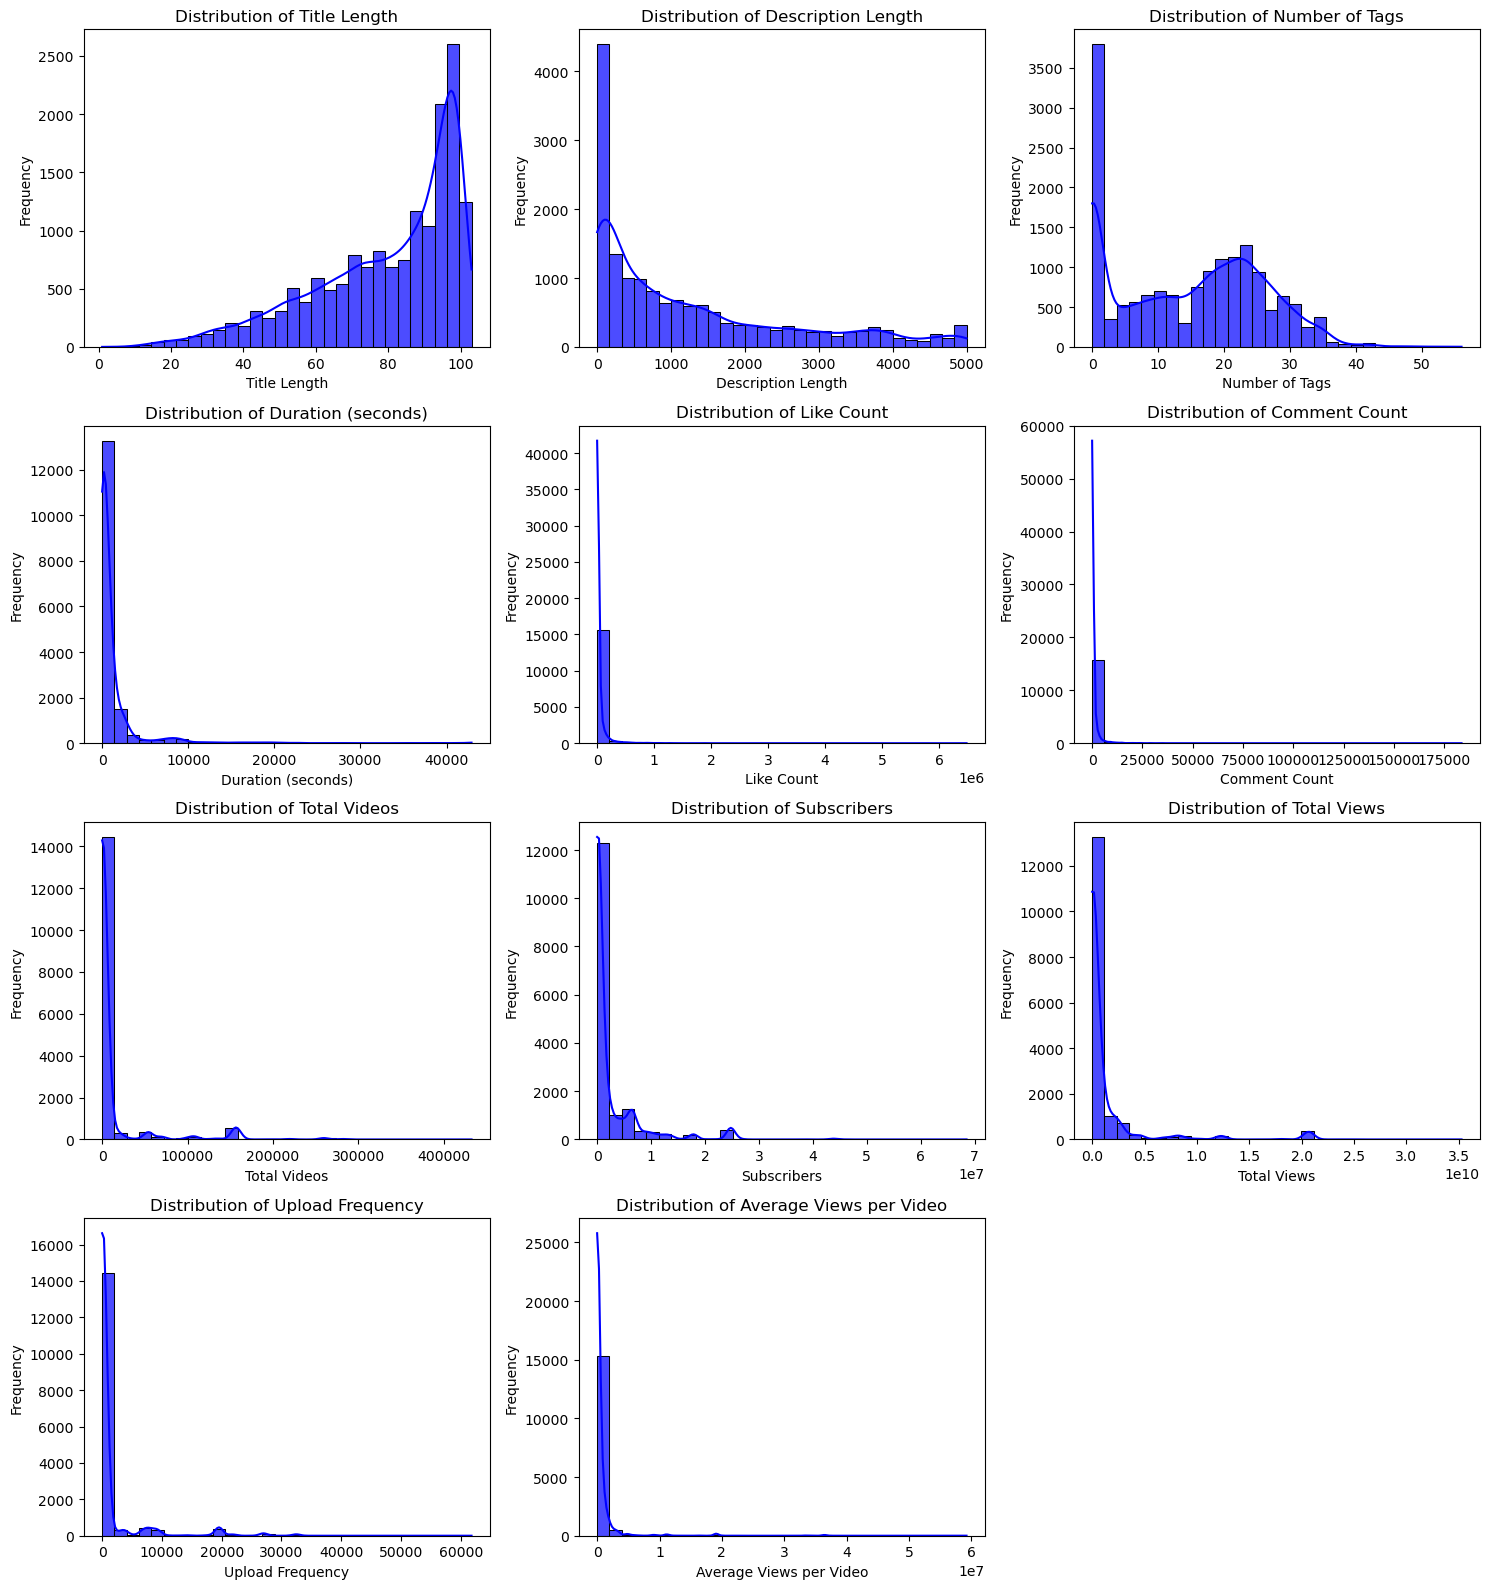

In [33]:
# Define the numerical columns you want to visualize
numerical_columns = [
    'Title Length', 'Description Length', 'Number of Tags', 'Duration (seconds)',
    'Like Count', 'Comment Count', 'Total Videos', 'Subscribers',
    'Total Views', 'Upload Frequency', 'Average Views per Video' 
]

# Set up the figure for multiple subplots
num_cols = 3  # Number of columns per row in the grid
num_rows = (len(numerical_columns) + num_cols - 1) // num_cols  # Calculate required rows
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, num_rows * 4))

# Flatten axes for easy indexing
axes = axes.flatten()

# Iterate over columns and create a histogram for each
for i, col in enumerate(numerical_columns):
    sns.histplot(df[col], kde=True, bins=30, ax=axes[i], color='blue', alpha=0.7)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Hide any extra subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Tight layout to adjust spacing
plt.tight_layout()
plt.show()


- Splitting the dataset using train test split keeping the test size 20% of the actual dataset
- during splitting we used stratify=y to keep the same proportion of data into both train and test set

In [35]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop(columns=['View Count Category'])
y = df['View Count Category']

# Stratified split to maintain target distribution
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Check distribution of columns in train and test sets
print("Train set distribution:")
print(y_train.value_counts(normalize=True))
print("\nTest set distribution:")
print(y_test.value_counts(normalize=True))

Train set distribution:
View Count Category
1k-50k      0.243101
0-1k        0.214656
50k-500k    0.206539
500k-3M     0.185592
>3M         0.150112
Name: proportion, dtype: float64

Test set distribution:
View Count Category
1k-50k      0.243277
0-1k        0.214529
50k-500k    0.206491
500k-3M     0.185781
>3M         0.149923
Name: proportion, dtype: float64


In [36]:
#descrive x train test sets
y_train.describe()

count      12937
unique         5
top       1k-50k
freq        3145
Name: View Count Category, dtype: object

In [37]:
X_train.describe()

,Title Length,Published Week Day,Publish Time,Description Length,Number of Tags,Duration (seconds),Definition,Like Count,Comment Count,Creation Year,Total Videos,Subscribers,Total Views,Upload Frequency,Average Views per Video,Category ID Mapped
count,12937.000000,12937.000000,12937.000000,12937.000000,12937.000000,12937.000000,12937.000000,1.293700e+04,12937.000000,12937.000000,12937.000000,1.293700e+04,1.293700e+04,12937.000000,1.293700e+04,12937.000000
mean,79.367164,2.932287,1.027595,1252.969931,14.678905,1347.328592,0.962124,3.737859e+04,734.338641,2019.076061,12005.377135,2.458660e+06,1.222369e+09,1487.383942,6.249472e+05,4.313829
std,19.826095,1.964250,1.104999,1361.933819,11.118515,3819.663521,0.190903,1.926904e+05,3303.687793,3.711987,39079.209395,5.466072e+06,3.652472e+09,4682.493171,2.676359e+06,2.833450
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,2005.000000,1.000000,0.000000e+00,0.000000e+00,0.071429,0.000000e+00,0.000000
25%,67.000000,1.000000,0.000000,142.000000,3.000000,47.000000,1.000000,3.100000e+01,1.000000,2017.000000,129.000000,3.560000e+03,5.287130e+05,33.333333,2.415929e+03,2.000000
50%,86.000000,3.000000,1.000000,743.000000,16.000000,294.000000,1.000000,1.374000e+03,37.000000,2020.000000,424.000000,1.340000e+05,2.522614e+07,94.000000,4.216289e+04,4.000000
75%,96.000000,5.000000,1.000000,1938.000000,23.000000,984.000000,1.000000,1.488800e+04,382.000000,2022.000000,1328.000000,1.890000e+06,5.386354e+08,260.000000,3.250970e+05,7.000000
max,103.000000,6.000000,4.000000,5000.000000,56.000000,42901.000000,1.000000,6.483718e+06,164061.000000,2024.000000,410137.000000,6.850000e+07,3.525861e+10,32460.500000,5.921592e+07,9.000000


- as there were high skewness in most of the columns, we decided to check for transformation algorithms.
- we checked 4 different transformation methods. (Logn, sqrt, Yeo-Johnson and Box-Cox)

Processing column: Title Length


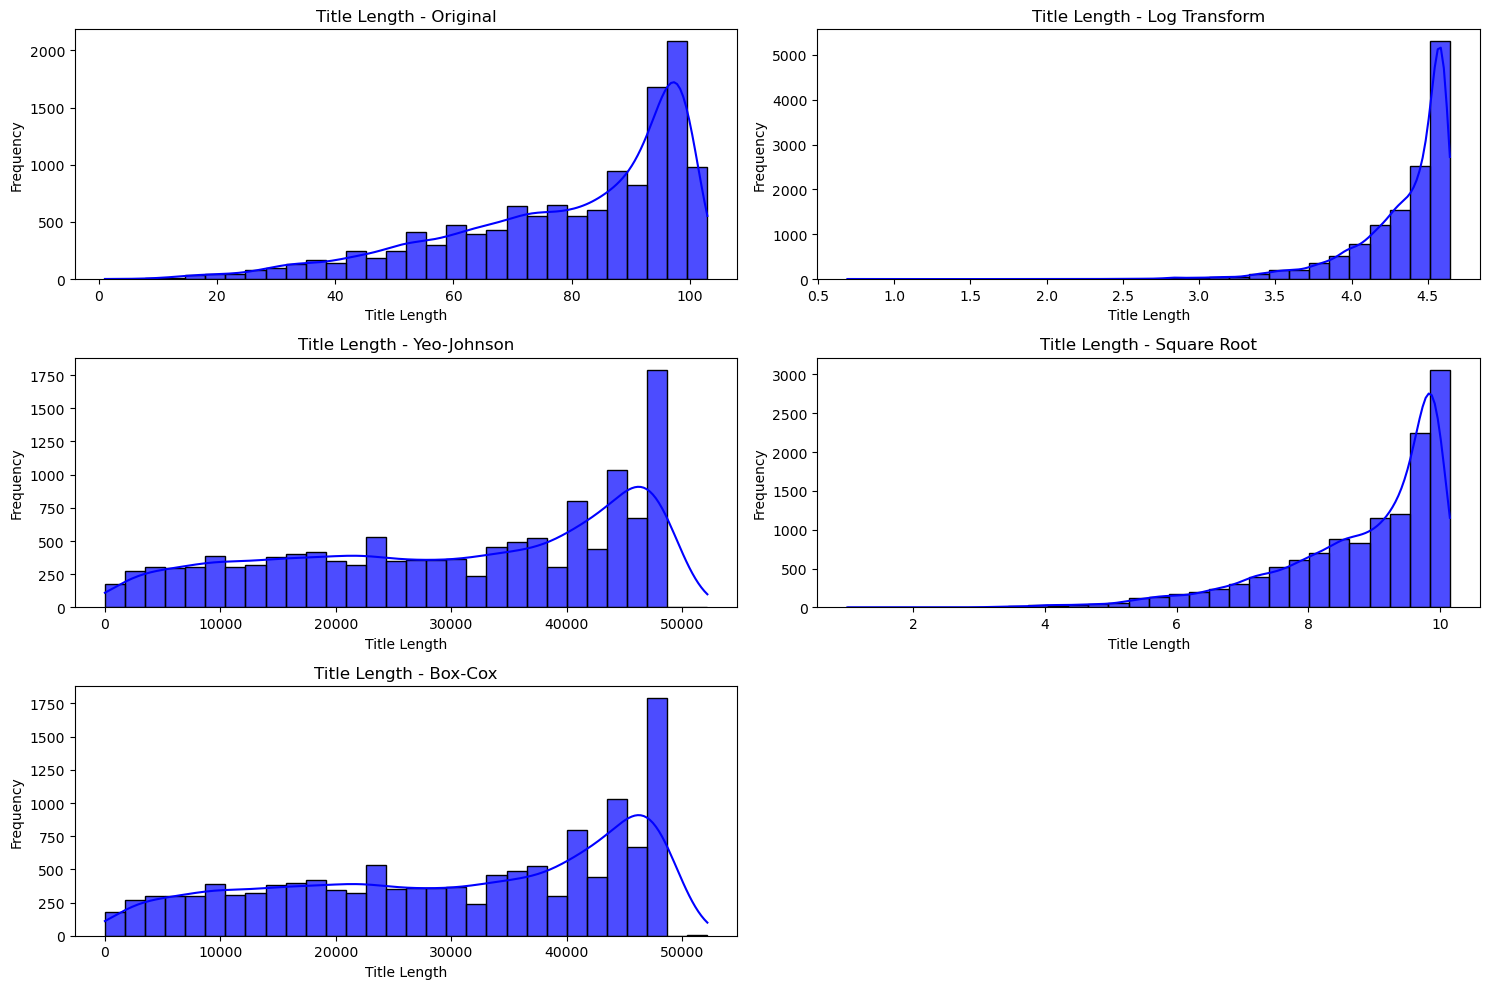

Processing column: Description Length


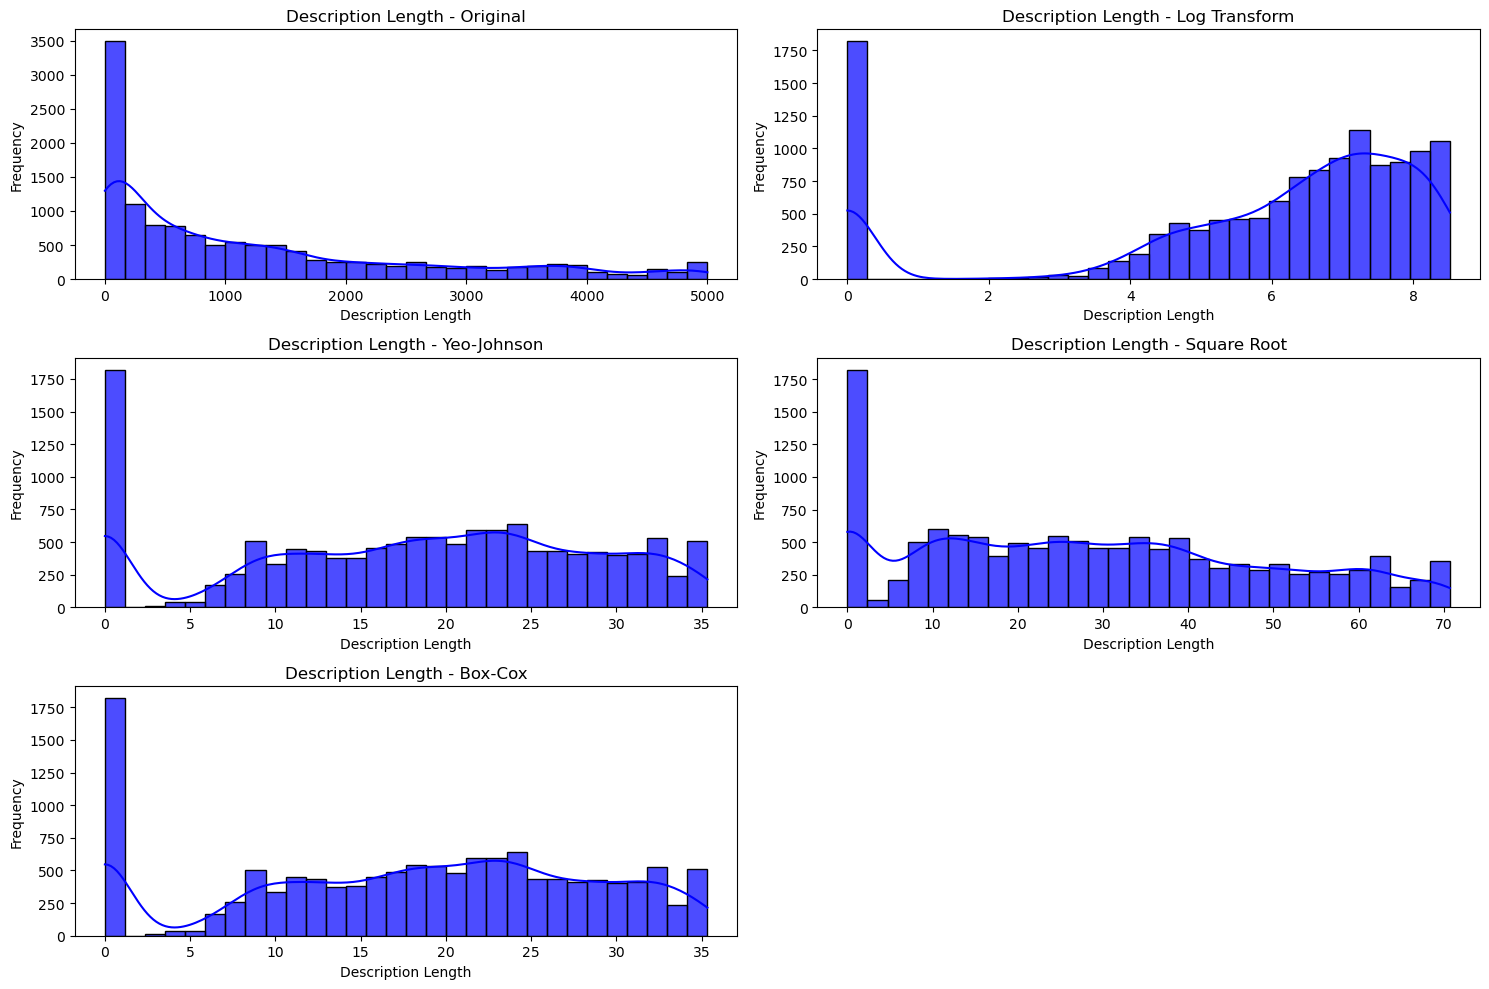

Processing column: Number of Tags


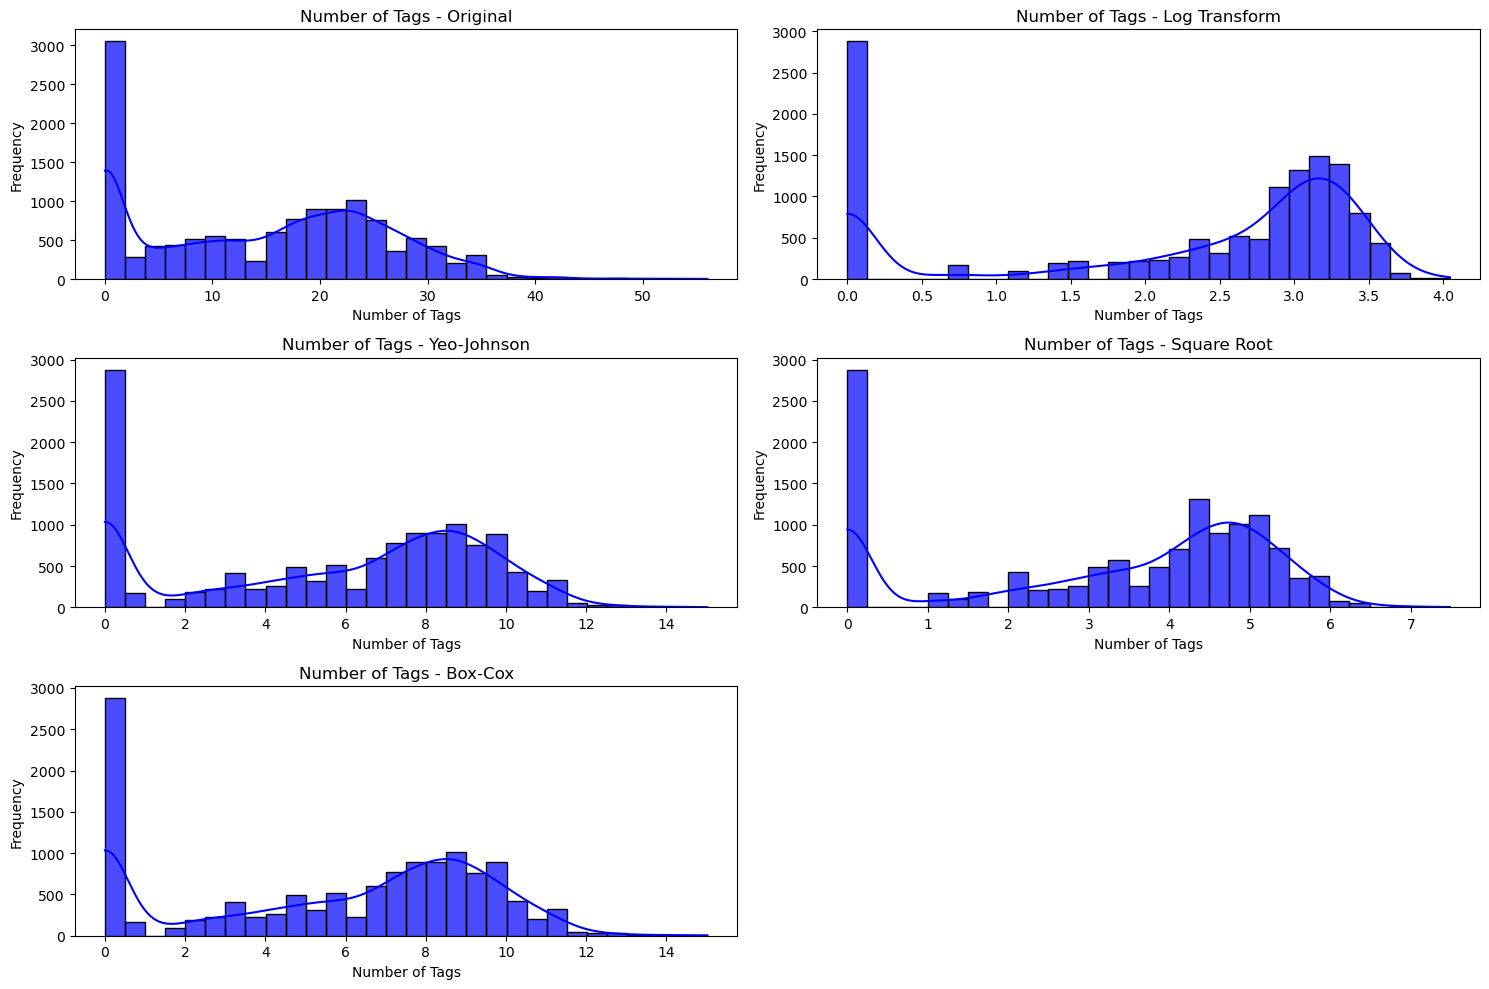

Processing column: Duration (seconds)


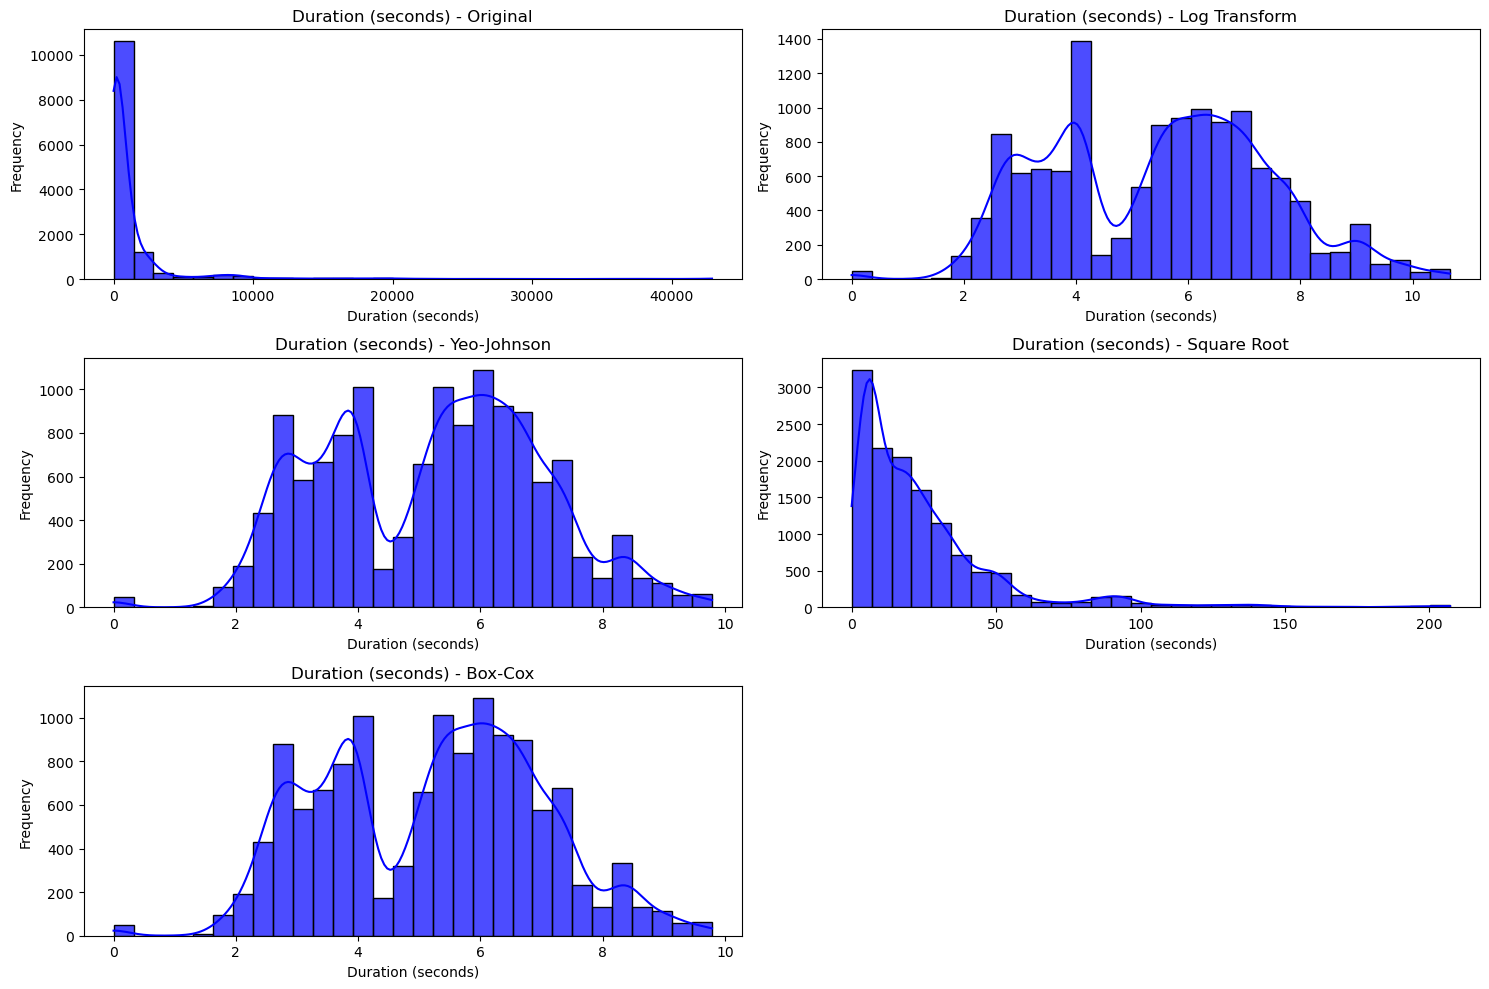

Processing column: Like Count


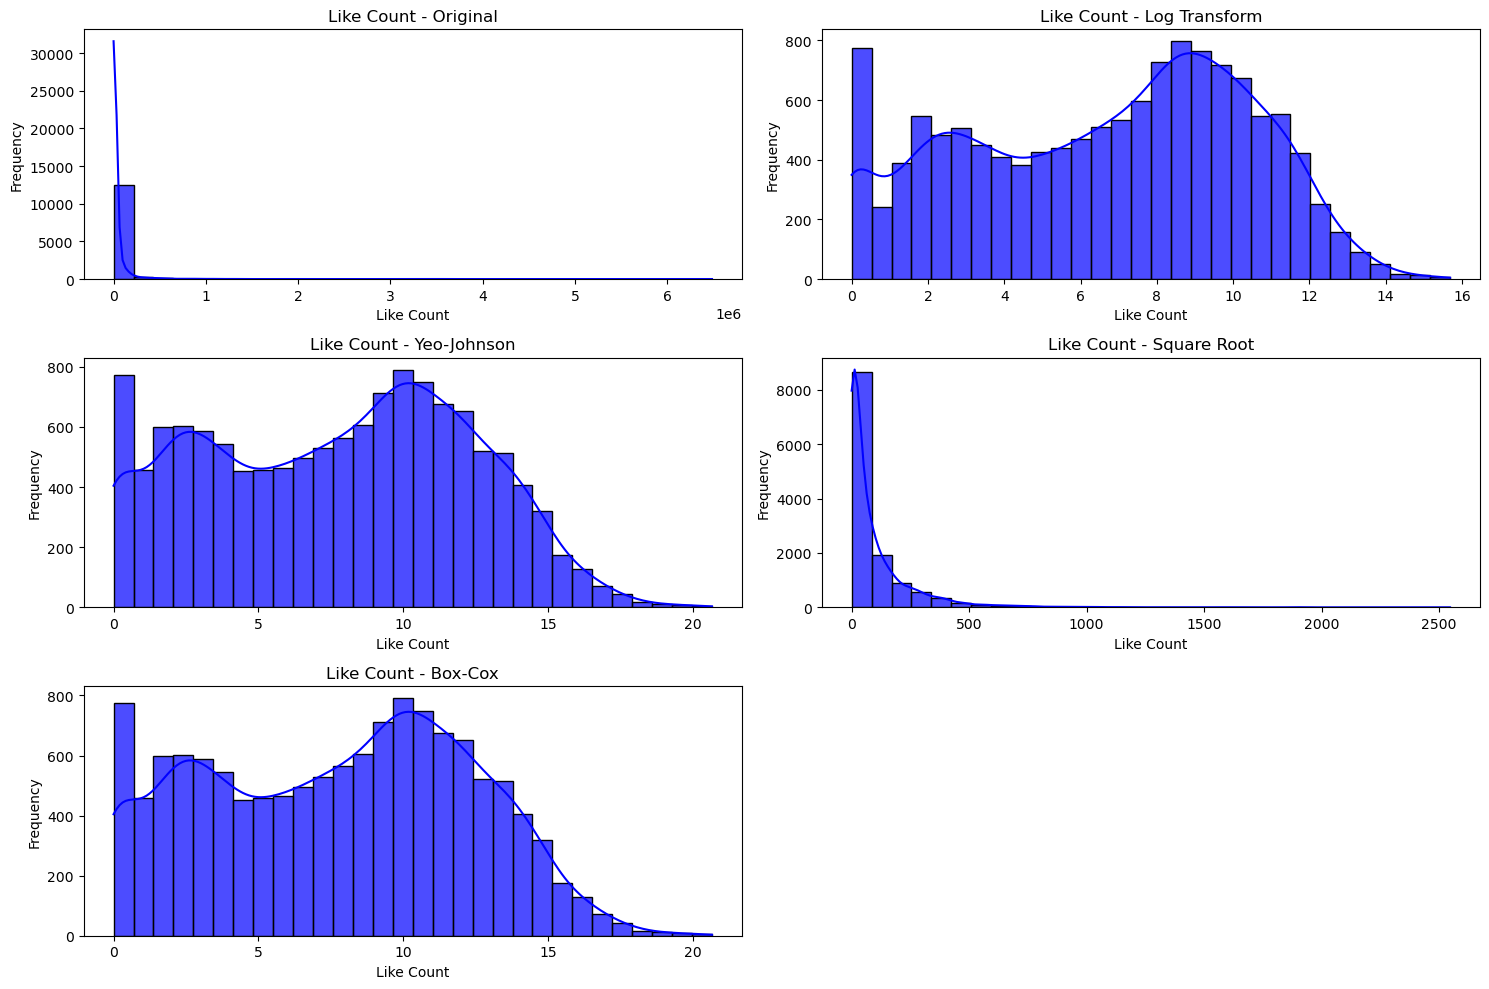

Processing column: Comment Count


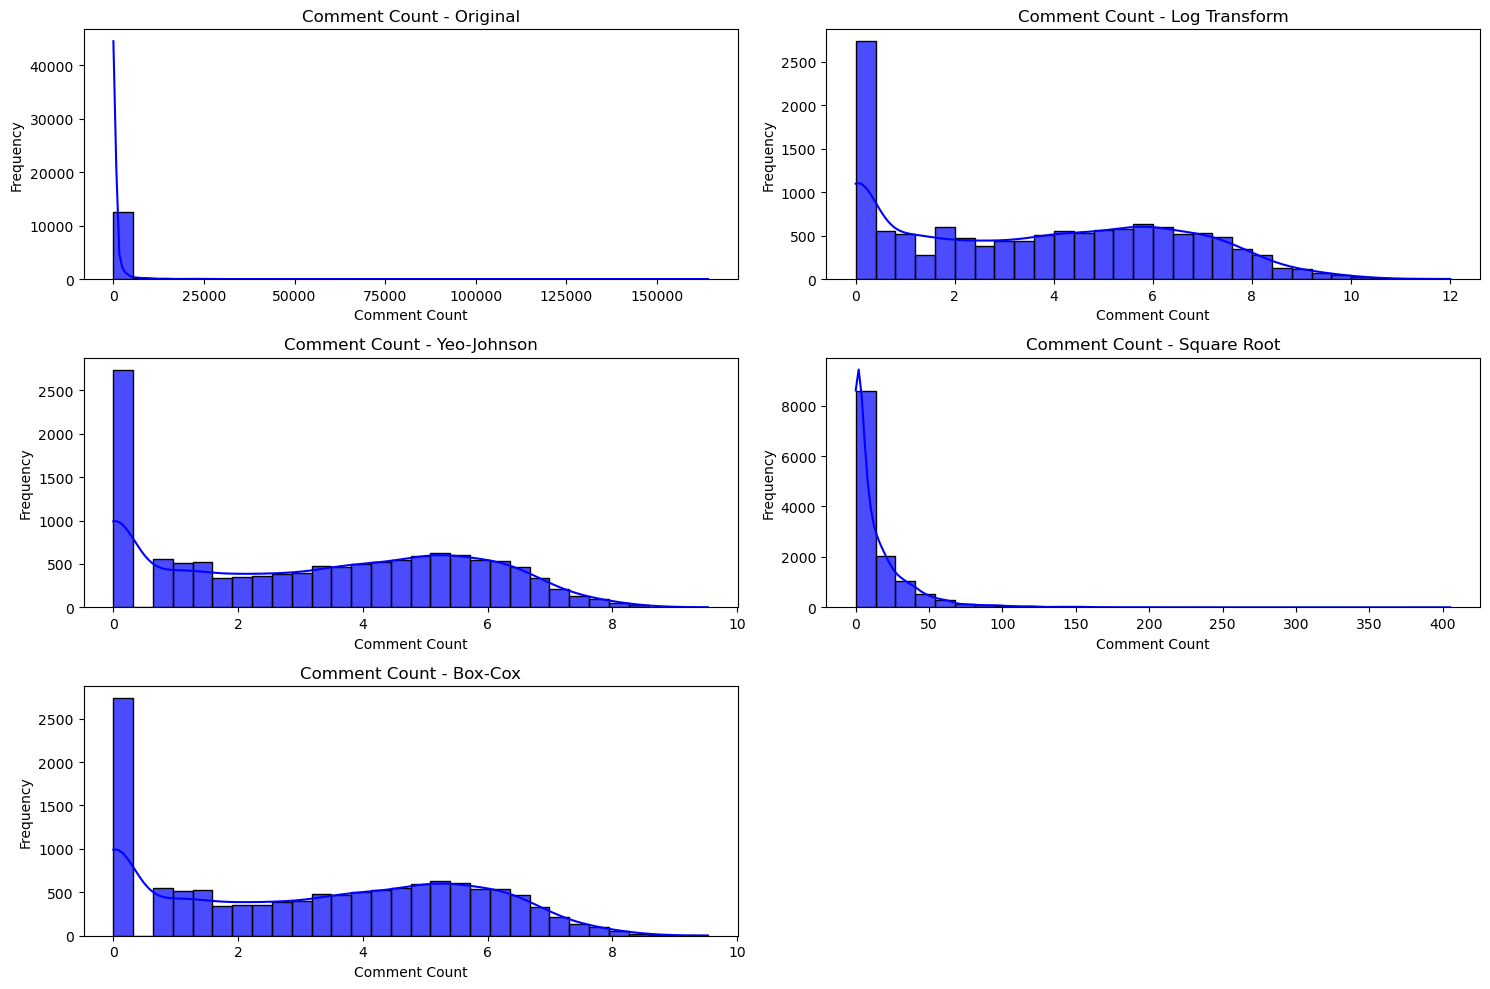

Processing column: Total Videos


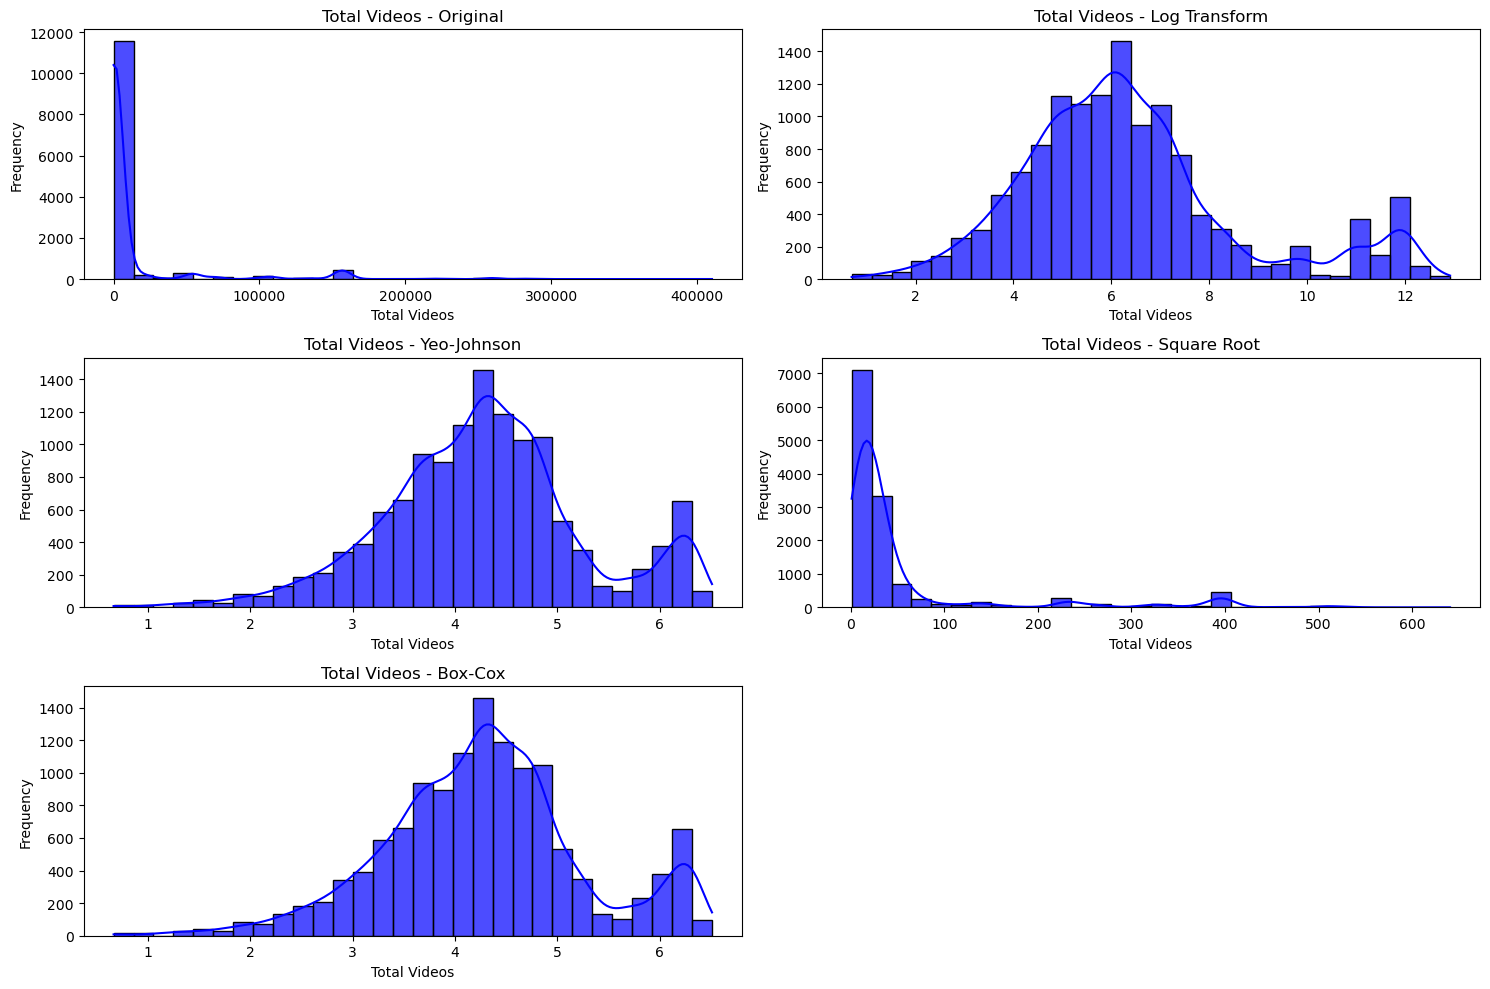

Processing column: Subscribers


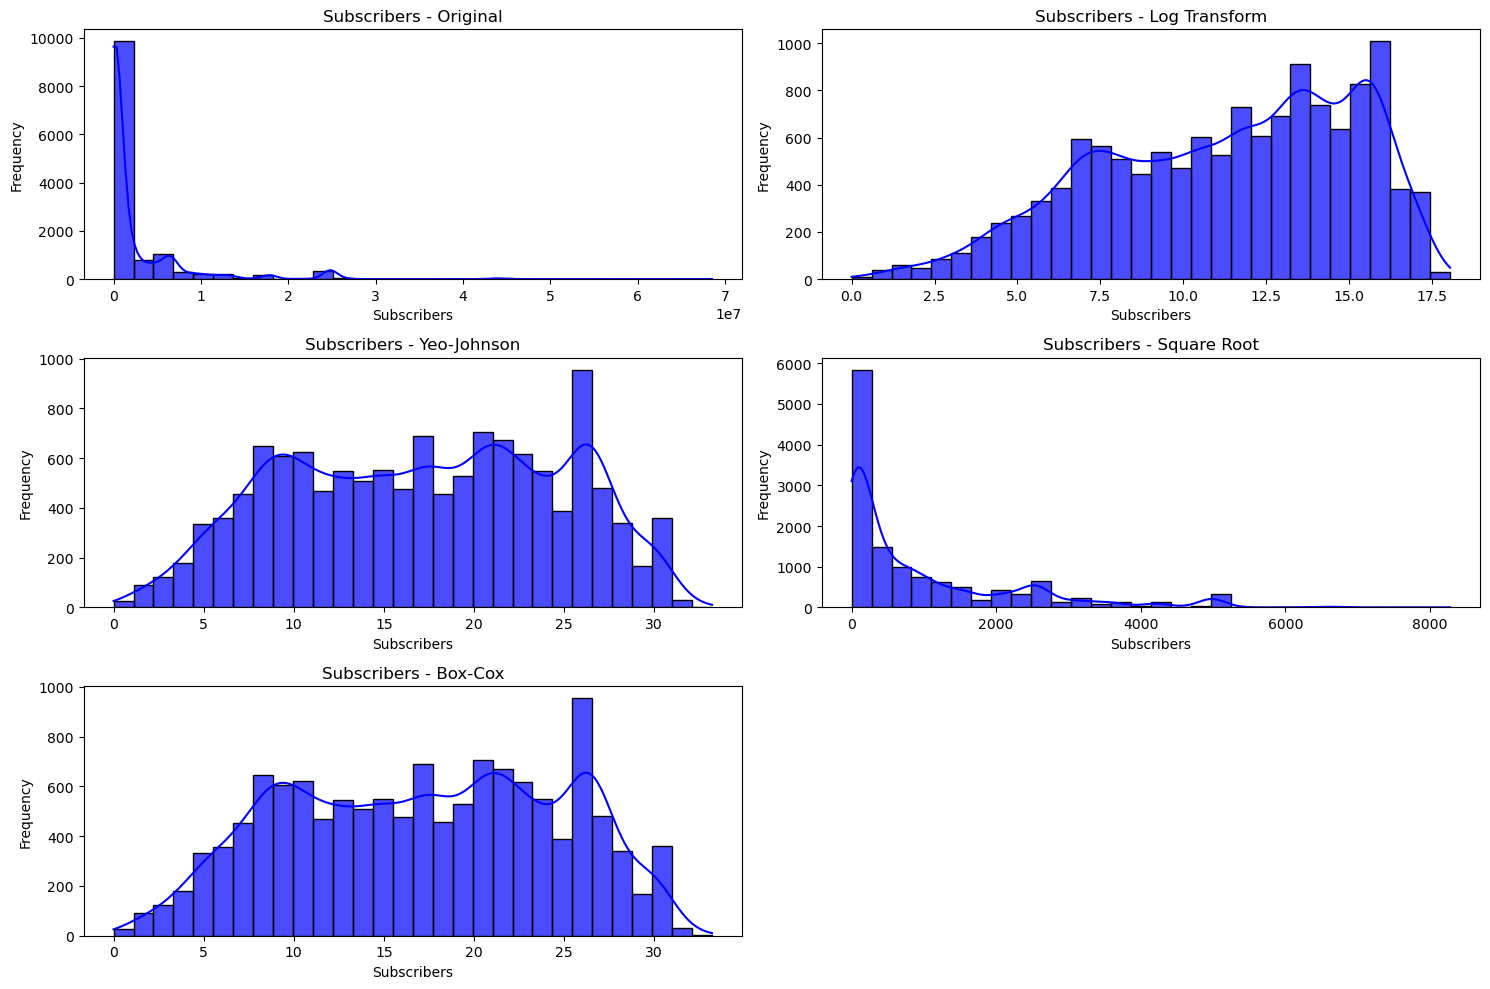

Processing column: Total Views


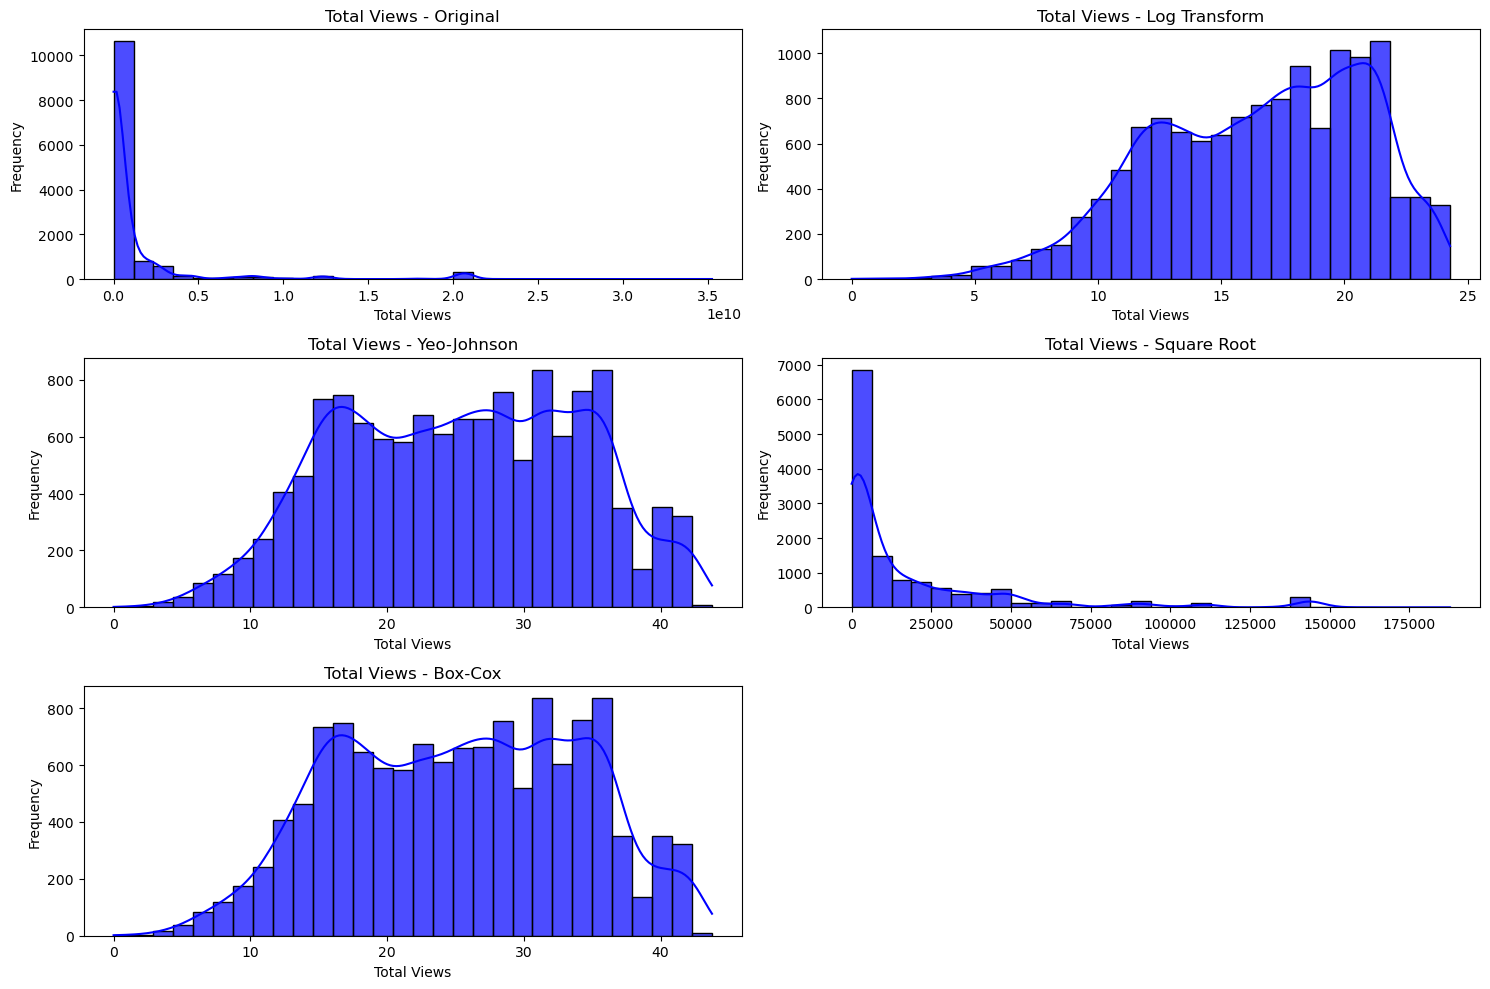

Processing column: Upload Frequency


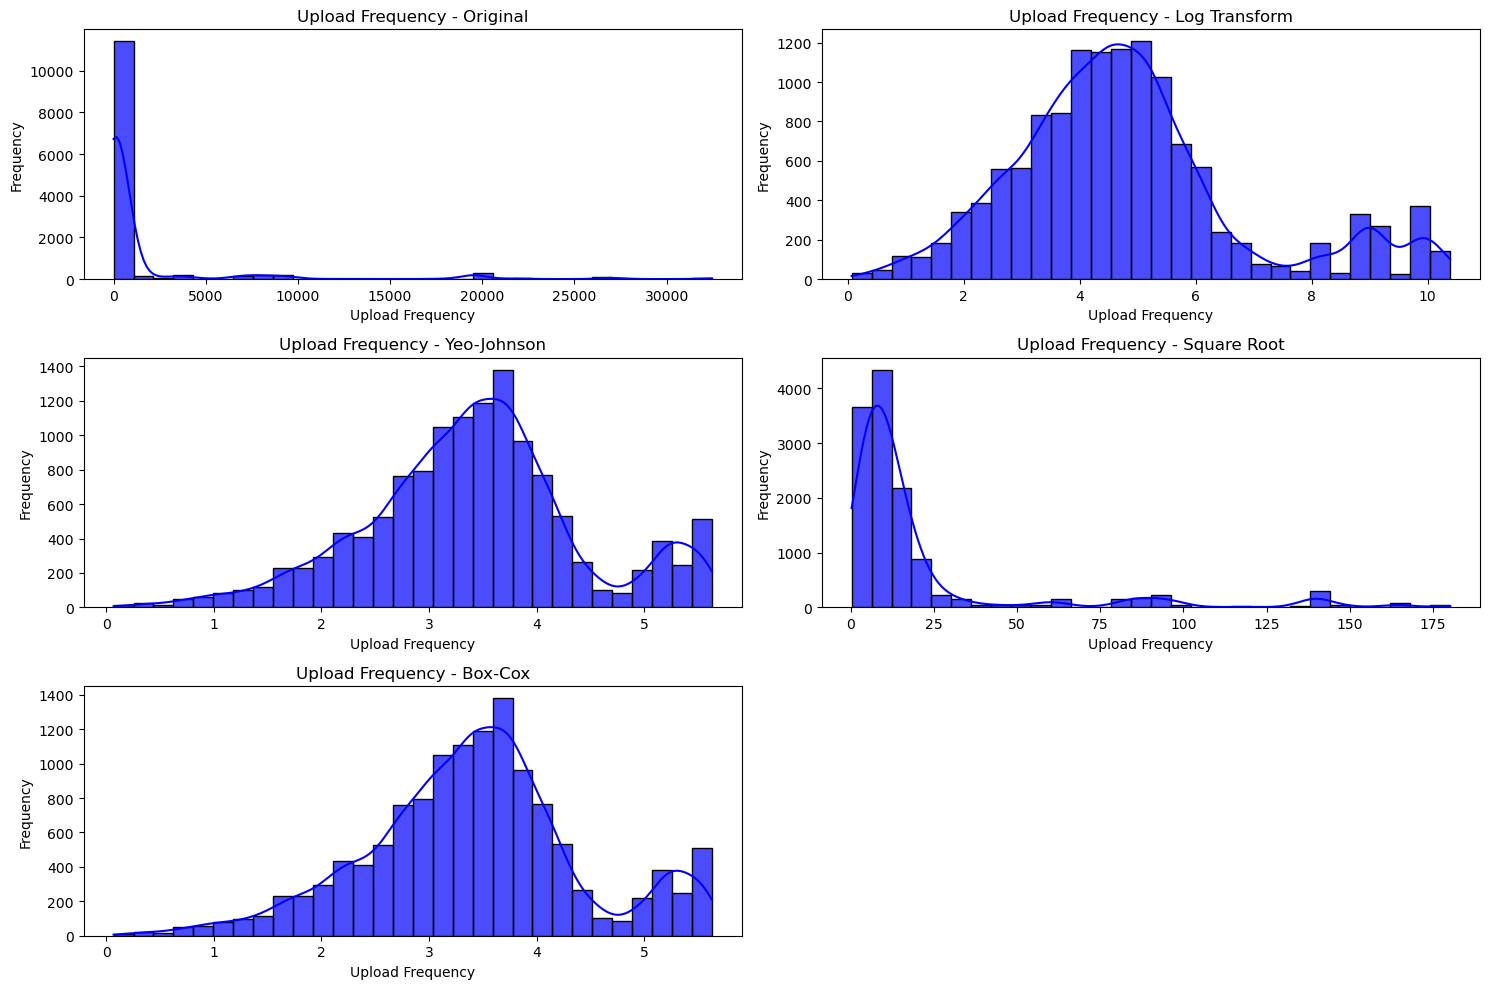

Processing column: Average Views per Video


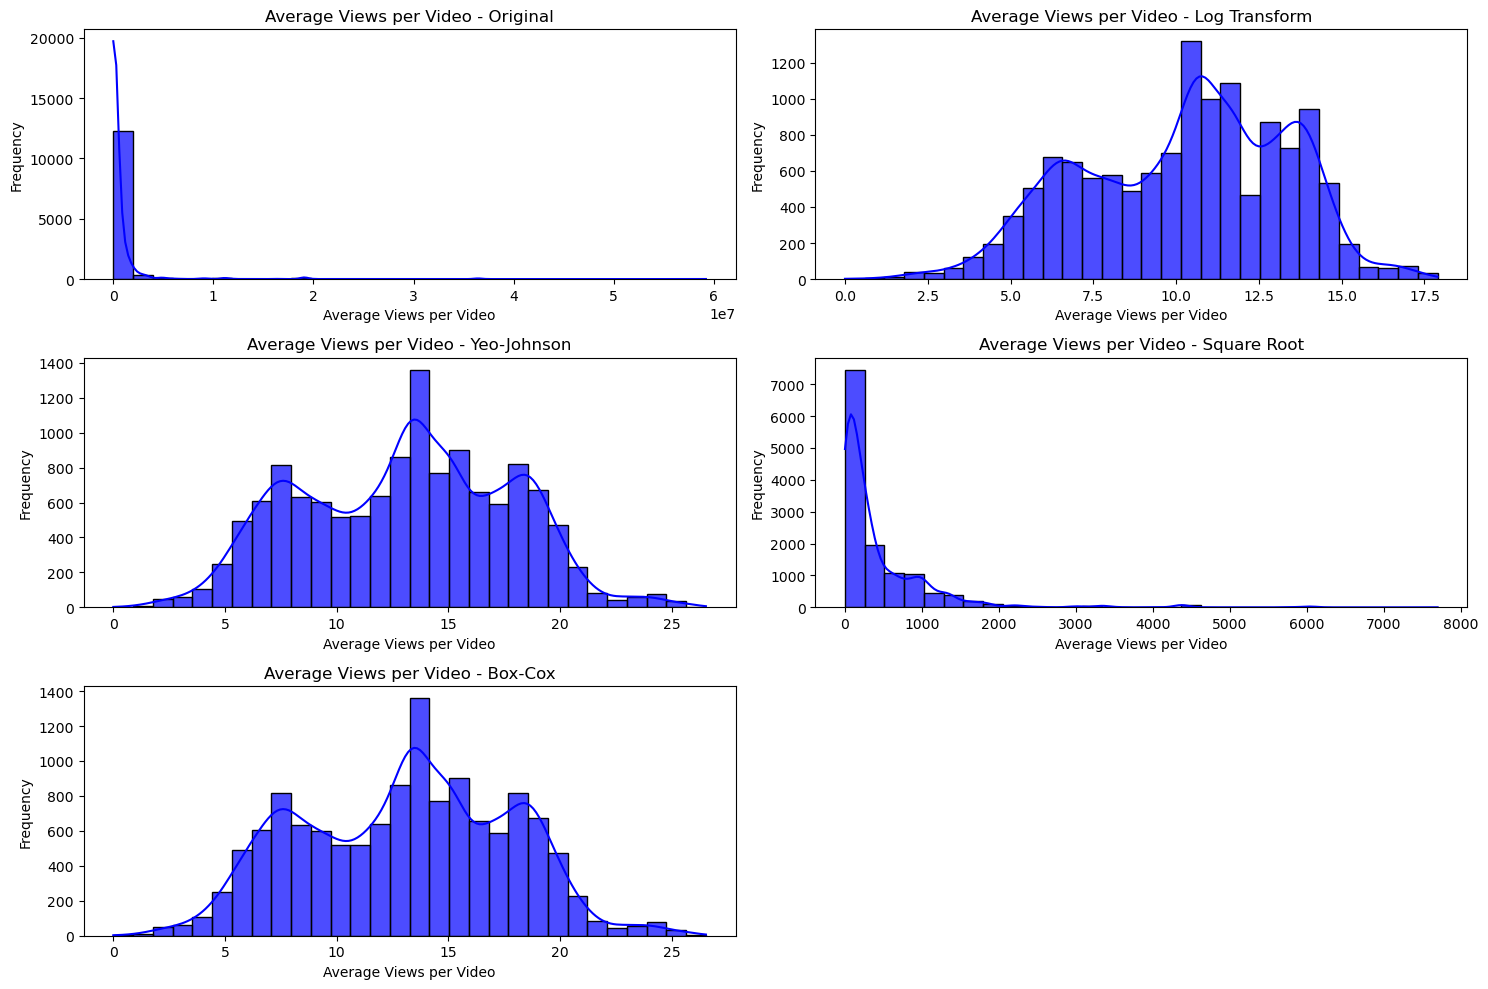

In [39]:
from scipy.stats import yeojohnson, boxcox
from sklearn.preprocessing import PowerTransformer

# List of numerical columns
numerical_columns = ['Title Length', 'Description Length', 'Number of Tags',
                     'Duration (seconds)', 'Like Count', 'Comment Count',
                     'Total Videos', 'Subscribers', 'Total Views',
                     'Upload Frequency', 'Average Views per Video']

# Create a copy of X_train to avoid overwriting original data
X_train_transformed = X_train.copy()

# Function to apply transformations and plot histograms
def check_transformations(data, columns):
    for col in columns:
        print(f"Processing column: {col}")

        # Original data
        original_data = data[col]

        # Log Transformation
        log_transformed = np.log1p(original_data)

        # Yeo-Johnson Transformation
        yeo_transformed, _ = yeojohnson(original_data + 1e-9)  # Adding small value to avoid zero issues

        # Square Root Transformation
        sqrt_transformed = np.sqrt(original_data)

        # Box-Cox Transformation (only for positive values)
        if original_data.min() >= 0:
            boxcox_transformed, _ = boxcox(original_data + 1)
        else:
            boxcox_transformed = None
            print(f"Box-Cox skipped for {col} (contains non-positive values).")

        # Prepare transformations for visualization
        transformations = {
            "Original": original_data,
            "Log Transform": log_transformed,
            "Yeo-Johnson": yeo_transformed,
            "Square Root": sqrt_transformed,
            "Box-Cox": boxcox_transformed if boxcox_transformed is not None else []
        }

        # Plot histograms
        plt.figure(figsize=(15, 10))
        for i, (name, transformed_data) in enumerate(transformations.items(), start=1):
            if len(transformed_data) == 0:  # Skip empty transformations
                continue
            plt.subplot(3, 2, i)
            sns.histplot(transformed_data, kde=True, bins=30, color='blue', alpha=0.7)
            plt.title(f"{col} - {name}")
            plt.xlabel(col)
            plt.ylabel("Frequency")

        plt.tight_layout()
        plt.show()

# Apply and visualize transformations
check_transformations(X_train_transformed, numerical_columns)


- we decided to use log transform for the right skewed columns, and yeo-johnson transform for left skewed columns(only Title Length)

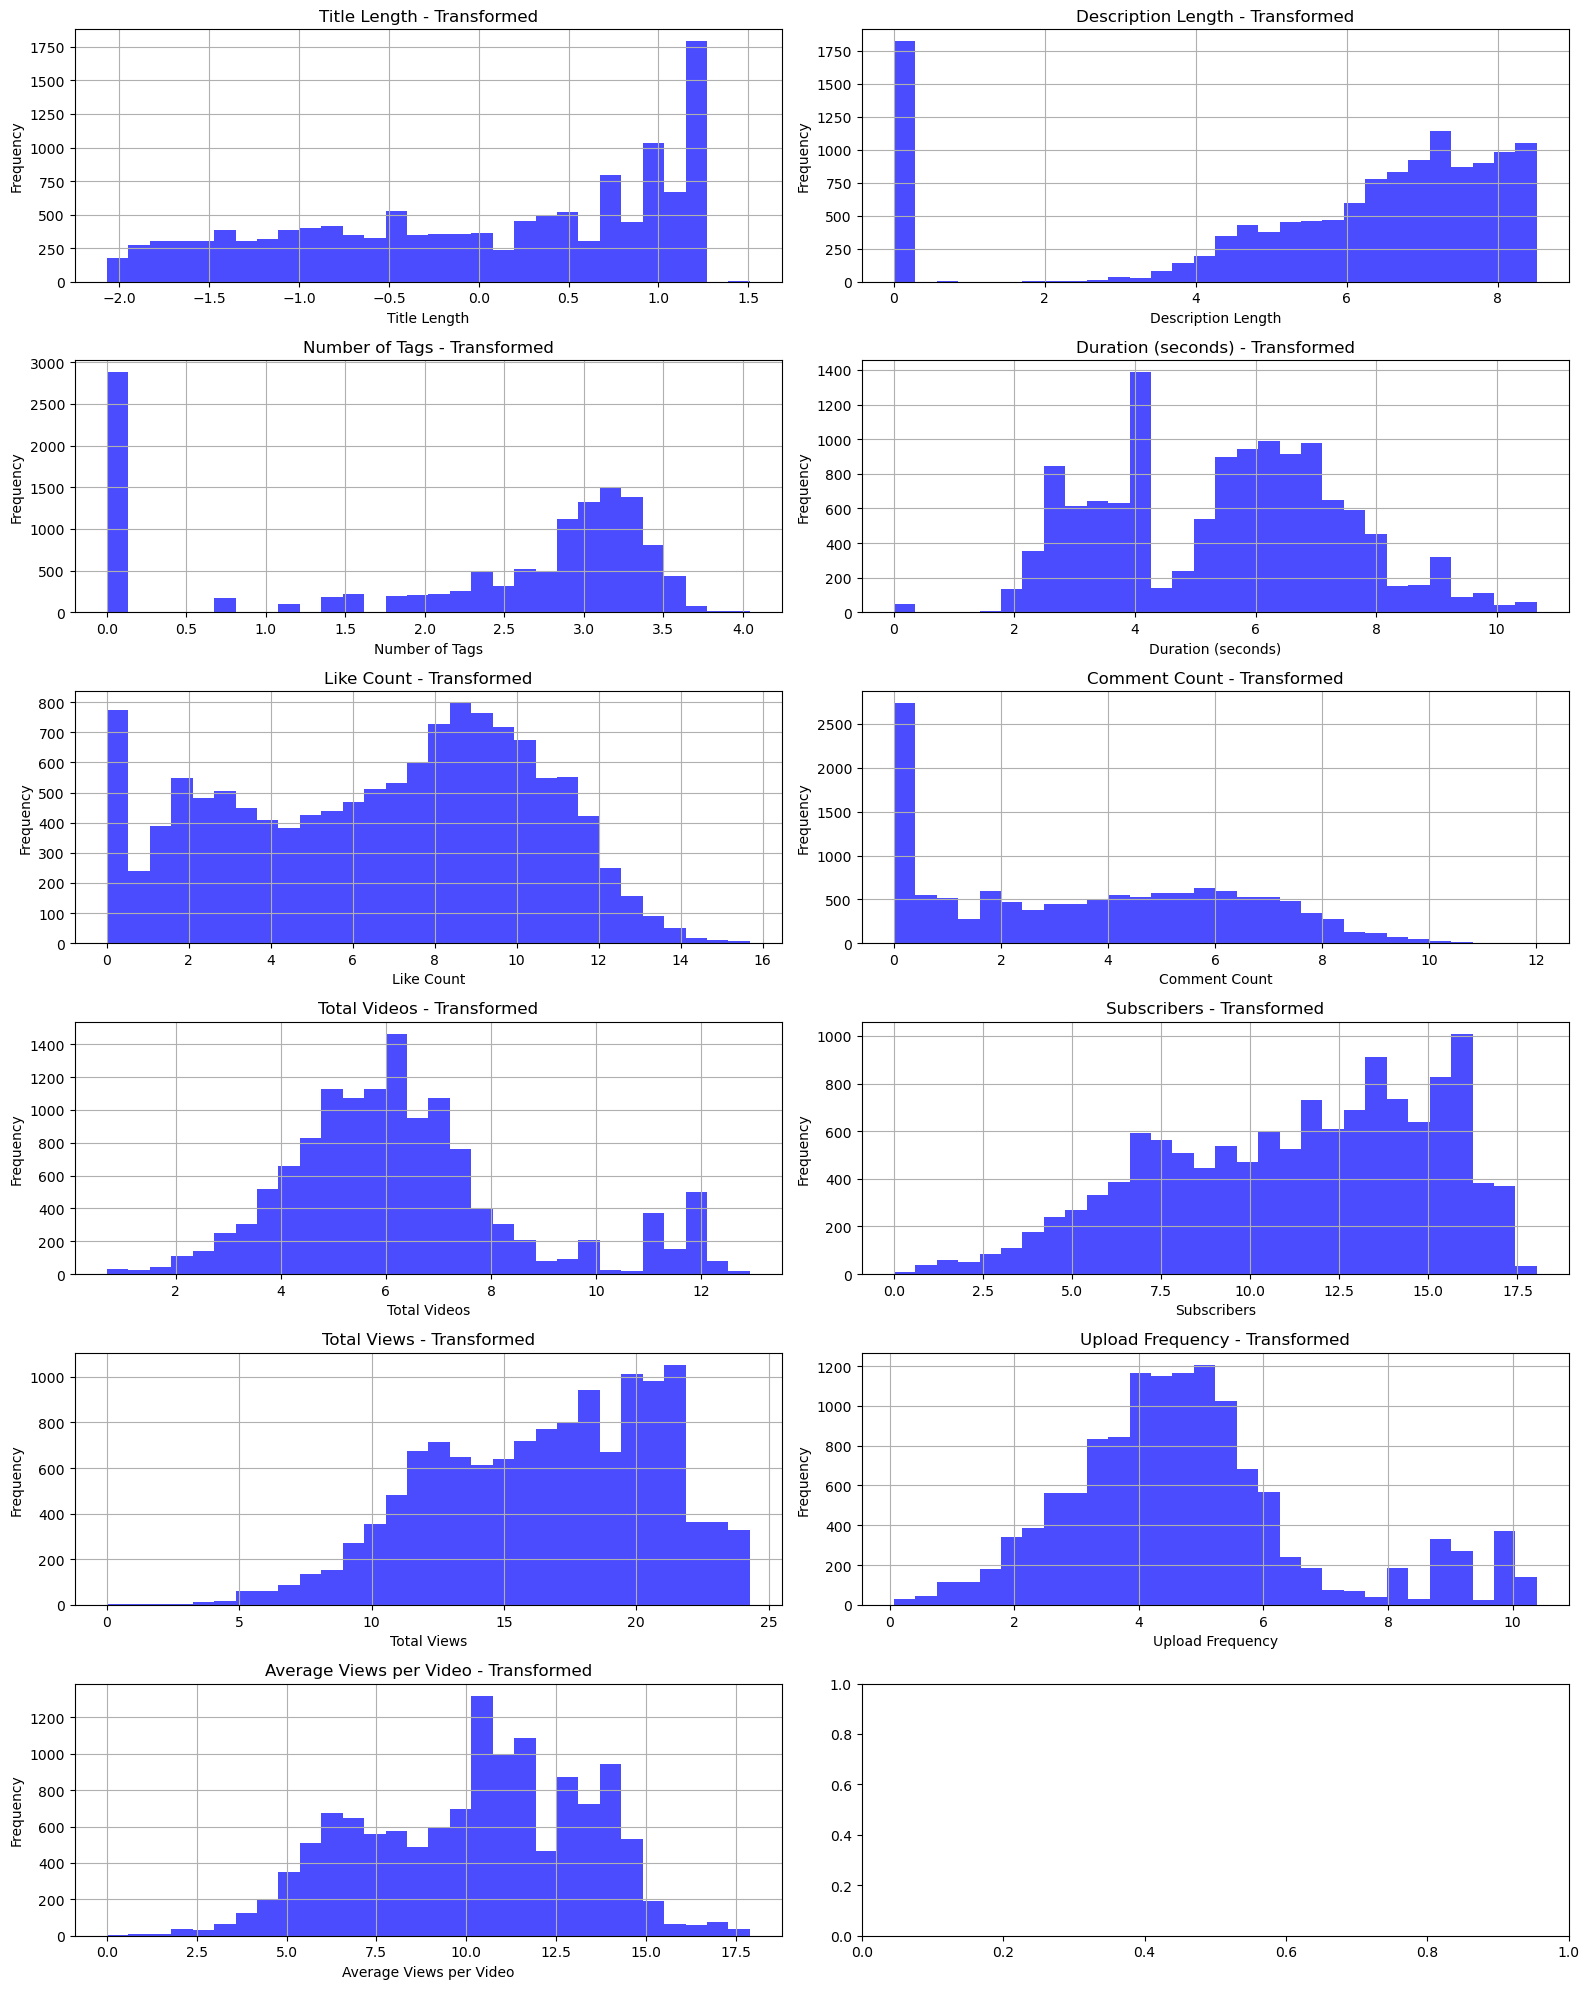

In [41]:
# List of numerical columns to log transform (except "Title Length")
numerical_columns = ['Description Length', 'Number of Tags',
                     'Duration (seconds)', 'Like Count', 'Comment Count',
                     'Total Videos', 'Subscribers', 'Total Views',
                     'Upload Frequency', 'Average Views per Video']

# Copy datasets for transformation
X_train_transformed = X_train.copy()
X_test_transformed = X_test.copy()

# Initialize Yeo-Johnson transformer for "Title Length"
yeo_johnson_transformer = PowerTransformer(method='yeo-johnson')

# Apply Yeo-Johnson transformation to "Title Length"
X_train_transformed['Title Length'] = yeo_johnson_transformer.fit_transform(X_train[['Title Length']])
X_test_transformed['Title Length'] = yeo_johnson_transformer.transform(X_test[['Title Length']])

# Apply log transformation to the remaining columns
for col in numerical_columns:
    X_train_transformed[col] = np.log1p(X_train[col])  # log1p(x) = log(x + 1)
    X_test_transformed[col] = np.log1p(X_test[col])

# Check transformed distributions (optional)
fig, axes = plt.subplots(len(numerical_columns) // 2 + 1, 2, figsize=(16, 20))
axes = axes.flatten()

for i, col in enumerate(['Title Length'] + numerical_columns):
    X_train_transformed[col].hist(bins=30, ax=axes[i], color='blue', alpha=0.7)
    axes[i].set_title(f"{col} - Transformed")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


- Check for outliers. dropped lower 0.2 and upper 0.2

In [43]:
#check for outliers and drop
def remove_outliers(data, columns):
    """
    Removes outliers based on IQR for specified columns.
    """
    data_clean = data.copy()
    for col in columns:
        Q1 = data_clean[col].quantile(0.20)
        Q3 = data_clean[col].quantile(0.80)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        # Filter the data within the bounds
        data_clean = data_clean[(data_clean[col] >= lower_bound) & (data_clean[col] <= upper_bound)]
    return data_clean

# Combine log-transformed and square root-transformed columns
all_transformed_columns = numerical_columns + ['Title Length']

# Remove outliers from training data
X_train_cleaned = remove_outliers(X_train_transformed, all_transformed_columns)
X_test_cleaned = remove_outliers(X_test_transformed, all_transformed_columns)

# Remove corresponding rows from target variable
y_train_cleaned = y_train[X_train_cleaned.index]
y_test_cleaned = y_test[X_test_cleaned.index]

# Check the shape of the cleaned data
print("Original Training Data Shape:", X_train.shape)
print("Cleaned Training Data Shape:", X_train_cleaned.shape)
print("Original Test Data Shape:", X_test.shape)
print("Cleaned Test Data Shape:", X_test_cleaned.shape)


Original Training Data Shape: (12937, 16)
Cleaned Training Data Shape: (12229, 16)
Original Test Data Shape: (3235, 16)
Cleaned Test Data Shape: (3065, 16)


- Used label encoder for y_train and y_test mapping as {'0-1k': 0, '1k-50k': 1, '500k-3M': 2, '50k-500k': 3, '>3M': 4}

In [45]:
from sklearn.preprocessing import LabelEncoder

# Create a LabelEncoder object
le = LabelEncoder()

# Fit the encoder to y_train
le.fit(y_train_cleaned)

# Display the mapping of labels to their encoded values
label_mapping = dict(zip(le.classes_, range(len(le.classes_))))
print("Label Mapping:", label_mapping)

# Encode y_train
y_train_cleaned = le.transform(y_train_cleaned)

# Encode y_test using the same encoder
y_test_cleaned = le.transform(y_test_cleaned)


Label Mapping: {'0-1k': 0, '1k-50k': 1, '500k-3M': 2, '50k-500k': 3, '>3M': 4}


In [46]:
X_train_cleaned.describe()

,Title Length,Published Week Day,Publish Time,Description Length,Number of Tags,Duration (seconds),Definition,Like Count,Comment Count,Creation Year,Total Videos,Subscribers,Total Views,Upload Frequency,Average Views per Video,Category ID Mapped
count,12229.000000,12229.000000,12229.000000,12229.000000,12229.000000,12229.000000,12229.000000,12229.000000,12229.000000,12229.000000,12229.000000,12229.000000,12229.000000,12229.000000,12229.000000,12229.000000
mean,-0.007381,2.944067,1.024287,5.643077,2.160354,5.448370,0.962466,6.574613,3.571590,2019.297162,6.002776,10.942987,16.164563,4.507580,10.174891,4.180146
std,1.005311,1.975722,1.109177,2.642594,1.316185,1.903656,0.190073,3.719999,2.812347,3.553117,1.838613,3.698507,4.070610,1.645892,3.148933,2.847908
min,-2.069954,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2005.000000,0.693147,0.000000,0.693147,0.068993,0.223144,0.000000
25%,-0.853390,1.000000,0.000000,4.787492,1.098612,3.850148,1.000000,3.295837,0.693147,2017.000000,4.820282,8.013343,12.968207,3.474625,7.577676,2.000000
50%,0.204742,3.000000,1.000000,6.535241,2.772589,5.676754,1.000000,7.080868,3.555348,2020.000000,5.945421,11.589896,16.672801,4.494859,10.590809,4.000000
75%,0.928742,5.000000,1.000000,7.461640,3.178054,6.825460,1.000000,9.610056,5.932245,2022.000000,6.988413,14.030623,19.687631,5.342334,12.802122,6.000000
max,1.509264,6.000000,4.000000,8.517393,4.043051,10.666627,1.000000,15.684805,12.008000,2024.000000,11.589220,17.639795,24.039772,9.104415,17.896701,9.000000


- used min max scaler for all the columns. 

In [48]:
from sklearn.preprocessing import MinMaxScaler

# Initialize the MinmaxScaler
scaler = MinMaxScaler()
all_columns = ['Title Length', 'Published Week Day', 'Publish Time', 'Description Length', 'Number of Tags',
                     'Duration (seconds)', 'Definition', 'Like Count', 'Comment Count', 'Creation Year',
                     'Total Videos', 'Subscribers', 'Total Views',
                     'Upload Frequency', 'Average Views per Video', 'Category ID Mapped']
# Scale the log-transformed features
X_train_scaled = X_train_cleaned.copy()
X_test_scaled = X_test_cleaned.copy()

X_train_scaled[all_columns] = scaler.fit_transform(X_train_cleaned[all_columns])
X_test_scaled[all_columns] = scaler.transform(X_test_cleaned[all_columns])

# Verify scaling (check medians and range instead of mean and std)
print("Scaled Training Data Summary (Median and IQR adjusted):")
print(X_train_scaled[all_columns].describe())


Scaled Training Data Summary (Median and IQR adjusted):
       Title Length  Published Week Day  Publish Time  Description Length  \
count  12229.000000        12229.000000  12229.000000        12229.000000   
mean       0.576264            0.490678      0.256072            0.662536   
std        0.280874            0.329287      0.277294            0.310258   
min        0.000000            0.000000      0.000000            0.000000   
25%        0.339897            0.166667      0.000000            0.562084   
50%        0.635529            0.500000      0.250000            0.767282   
75%        0.837808            0.833333      0.250000            0.876047   
max        1.000000            1.000000      1.000000            1.000000   

       Number of Tags  Duration (seconds)    Definition    Like Count  \
count    12229.000000        12229.000000  12229.000000  12229.000000   
mean         0.534337            0.510787      0.962466      0.419171   
std          0.325542          

- Calcualted the feature importance for all the columns

                    Feature  Importance
7                Like Count    0.381994
8             Comment Count    0.128680
14  Average Views per Video    0.111458
12              Total Views    0.057536
11              Subscribers    0.056494
5        Duration (seconds)    0.048591
3        Description Length    0.033983
10             Total Videos    0.030388
13         Upload Frequency    0.027721
0              Title Length    0.026798
15       Category ID Mapped    0.026172
4            Number of Tags    0.024429
9             Creation Year    0.019068
1        Published Week Day    0.014977
2              Publish Time    0.009652
6                Definition    0.002058


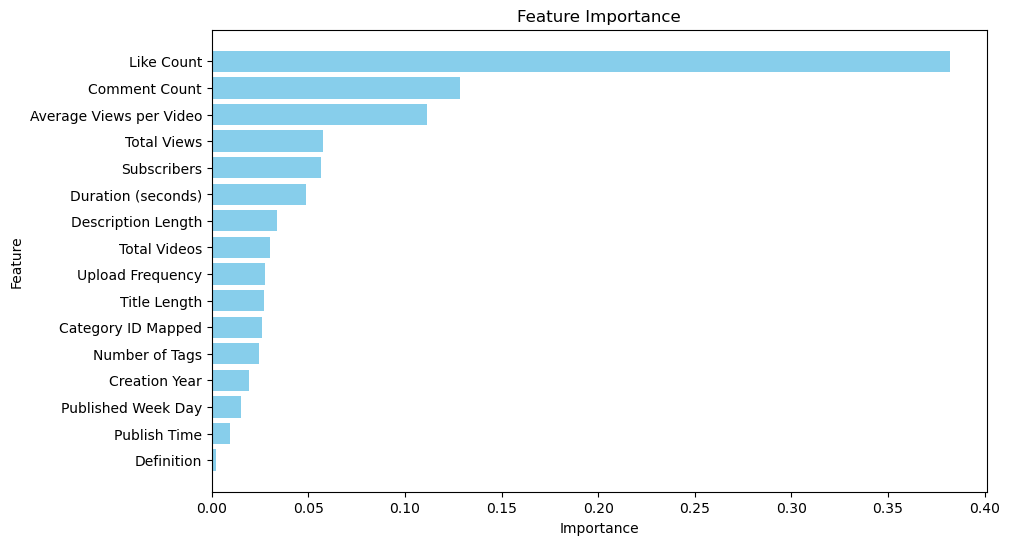

In [50]:
from sklearn.ensemble import RandomForestClassifier

# Train a simple model to calculate feature importance
model = RandomForestClassifier(random_state=42)
model.fit(X_train_scaled, y_train_cleaned)

# Get feature importance scores
importances = model.feature_importances_
feature_importance = pd.DataFrame({'Feature': X_train_scaled.columns, 'Importance': importances})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

# Display feature importance
print(feature_importance)

# Plot feature importance

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance')
plt.gca().invert_yaxis()
plt.show()


- dropped the less important columns, keeping the threshold value as 0.03

In [52]:
# Select important features based on a threshold
threshold = 0.03
selected_features = feature_importance[feature_importance['Importance'] > threshold]['Feature']

# Subset the train and test sets
X_train_selected = X_train_scaled[selected_features]
X_test_selected = X_test_scaled[selected_features]

print("Selected Features:")
print(selected_features)


Selected Features:
7                  Like Count
8               Comment Count
14    Average Views per Video
12                Total Views
11                Subscribers
5          Duration (seconds)
3          Description Length
10               Total Videos
Name: Feature, dtype: object


- visualized the correlation matrix of the remaining columns

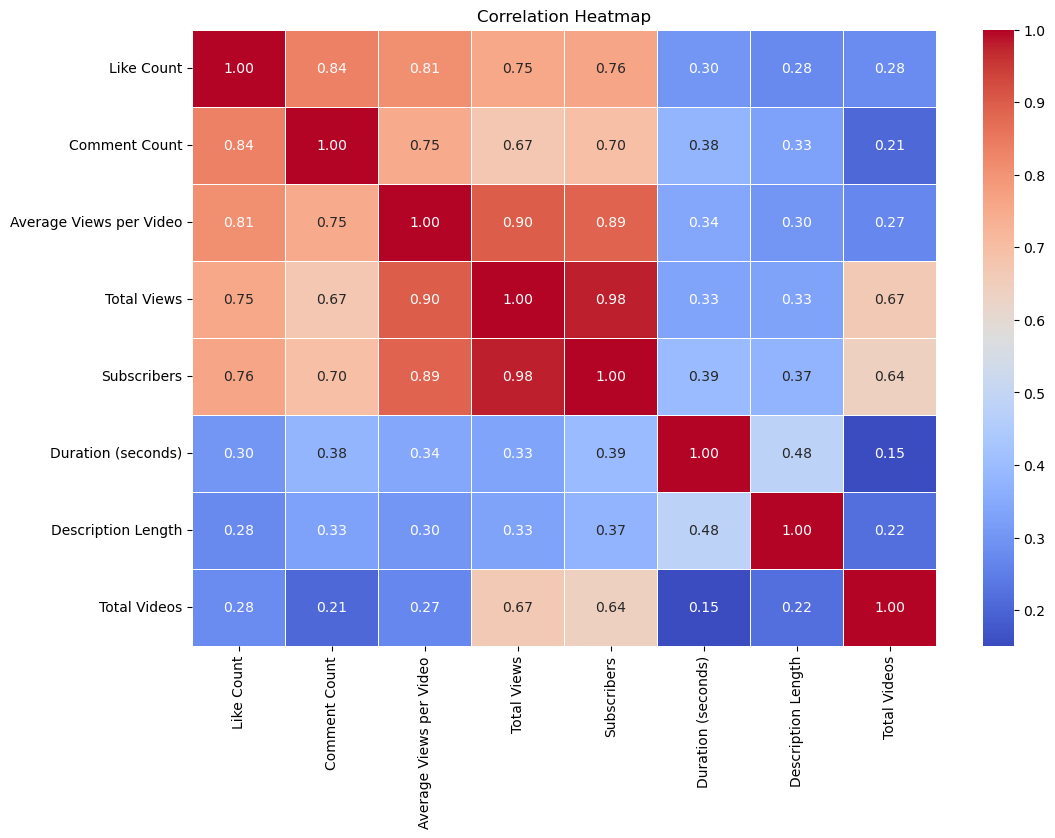

In [54]:

# Compute the correlation matrix
correlation_matrix = X_train_selected.corr()

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()


- dropped 2 columns 'Total Views', 'Total Videos' as they have high correlation(>0.9) with other columns.
  

In [56]:
#drop total views and upload frequency
X_train_selected = X_train_selected.drop(columns=['Total Views', 'Subscribers'])
X_test_selected = X_test_selected.drop(columns=['Total Views', 'Subscribers'])


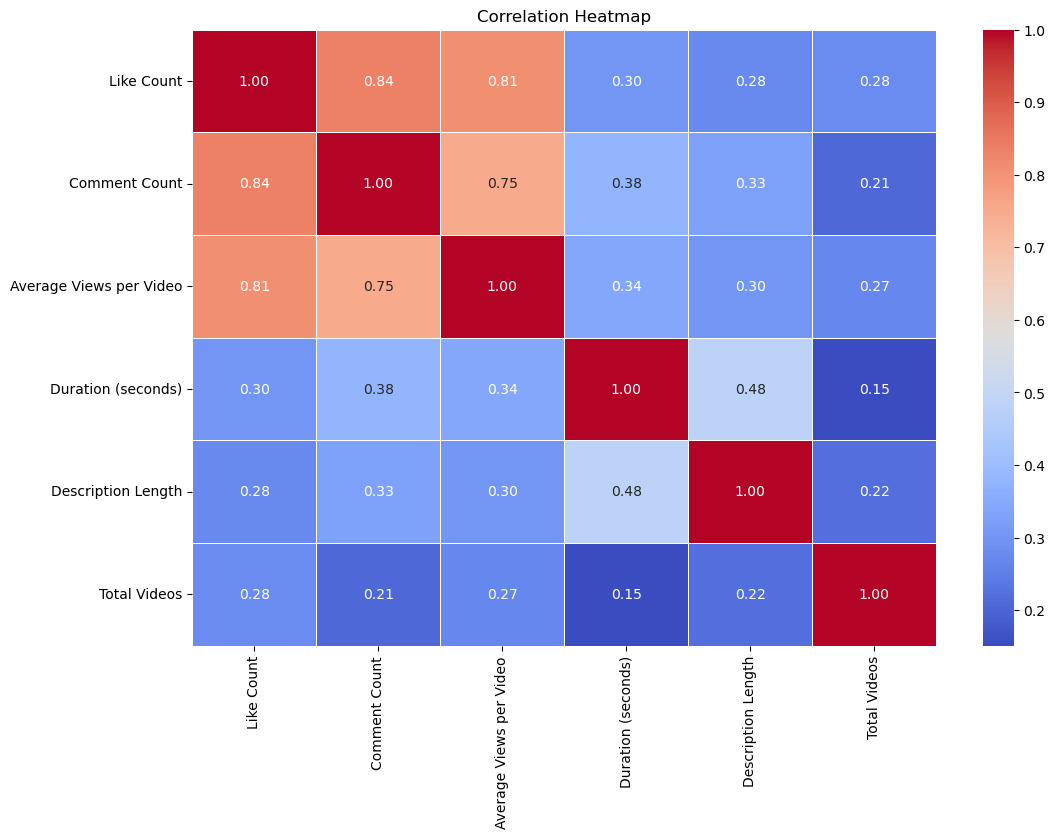

In [57]:
# Compute the correlation matrix
correlation_matrix = X_train_selected.corr()

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()


In [58]:
#view X_train_selected
print(X_train_selected.head())


       Like Count  Comment Count  Average Views per Video  Duration (seconds)  \
3095     0.114235       0.000000                 0.212020            0.362926   
15840    0.623513       0.495989                 0.594336            0.650557   
7015     0.270867       0.091490                 0.589931            0.519495   
15457    0.559019       0.409115                 0.594336            0.689594   
19593    0.197072       0.191754                 0.414129            0.444839   

       Description Length  Total Videos  
3095             0.595124      0.000000  
15840            0.971556      0.935959  
7015             0.000000      0.569893  
15457            0.969565      0.935959  
19593            0.676873      0.478107  


HyperParameter Tuninig

- Used RandomizaedSearchCV with KNN to find the best parameters

In [61]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV

# Define the KNN model
knn_model = KNeighborsClassifier()

# Hyperparameter grid
param_distributions = {
    'n_neighbors': list(range(1, 31)),  # Number of neighbors
    'weights': ['uniform', 'distance'],  # Weight function used in prediction
    'metric': ['euclidean', 'manhattan', 'chebyshev', 'minkowski'],  # Distance metric
    'p': [1, 2]  # Power parameter for the Minkowski metric
}

# RandomizedSearchCV
random_search_knn = RandomizedSearchCV(
    estimator=knn_model,
    param_distributions=param_distributions,
    scoring='accuracy',
    cv=3,
    n_iter=50,
    random_state=42,
    verbose=1,
    n_jobs=-1
)

# Fit RandomizedSearchCV
random_search_knn.fit(X_train_selected, y_train_cleaned)

# Best parameters and score
print("Best Parameters for KNN:", random_search_knn.best_params_)
print("Best Accuracy for KNN:", random_search_knn.best_score_)


Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best Parameters for KNN: {'weights': 'distance', 'p': 2, 'n_neighbors': 21, 'metric': 'manhattan'}
Best Accuracy for KNN: 0.8050532242875513


- Used RandomizaedSearchCV with RandomForestClassifier to find the best parameters

In [63]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score

# Define the parameter distribution
param_dist = {
    'n_estimators': [50, 100, 200, 300],       # Number of trees in the forest
    'max_depth': [None, 10, 20, 30, 40, 50],   # Maximum depth of the tree
    'min_samples_split': [2, 5, 10, 15],       # Minimum samples required to split an internal node
    'min_samples_leaf': [1, 2, 4, 6],          # Minimum samples required to be at a leaf node
    'criterion': ['gini', 'entropy'],          # Splitting criterion
    'bootstrap': [True, False]                 # Whether bootstrap samples are used when building trees
}

# Initialize the RandomForestClassifier
rf = RandomForestClassifier(random_state=42)

# Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=50,               # Number of random parameter combinations to test
    cv=5,                    # 5-fold cross-validation
    scoring='accuracy',      # Evaluate based on accuracy
    n_jobs=-1,               # Use all processors
    random_state=42,         # For reproducibility
    verbose=2                # Show progress
)

# Perform the search
random_search.fit(X_train_selected, y_train_cleaned)

# Display the best parameters and best score
print("Best Parameters:", random_search.best_params_)
print("Best Cross-Validation Score: {:.3f}".format(random_search.best_score_))

# Evaluate the best estimator on the test set
best_rf = random_search.best_estimator_
test_predictions = best_rf.predict(X_test_selected)
test_accuracy = accuracy_score(y_test_cleaned, test_predictions)
print("Test Set Accuracy: {:.3f}".format(test_accuracy))


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 30, 'criterion': 'gini', 'bootstrap': False}
Best Cross-Validation Score: 0.848
Test Set Accuracy: 0.855


- Used RandomizaedSearchCV with DecisionTreeClassifier to find the best parameters

In [65]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score

# Define the parameter distribution
param_dist = {
    'criterion': ['gini', 'entropy'],          # Splitting criteria
    'max_depth': [None, 10, 20, 30, 40],       # Maximum depth of the tree
    'min_samples_split': [2, 5, 10, 15],       # Minimum samples required to split an internal node
    'min_samples_leaf': [1, 2, 4, 6],          # Minimum samples required to be at a leaf node
    'splitter': ['best', 'random']             # Strategy used to choose the split
}

# Initialize the DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)

# Initialize RandomizedSearchCV
random_search_dt = RandomizedSearchCV(
    estimator=dt,
    param_distributions=param_dist,
    n_iter=50,               # Number of random parameter combinations to test
    cv=5,                    # 5-fold cross-validation
    scoring='accuracy',      # Evaluate based on accuracy
    n_jobs=-1,               # Use all processors
    random_state=42,         # For reproducibility
    verbose=2                # Show progress
)

# Perform the search
random_search_dt.fit(X_train_selected, y_train_cleaned)

# Display the best parameters and best score
print("Best Parameters:", random_search_dt.best_params_)
print("Best Cross-Validation Score: {:.3f}".format(random_search_dt.best_score_))

# Evaluate the best estimator on the test set
best_dt = random_search_dt.best_estimator_
test_predictions = best_dt.predict(X_test_selected)
test_accuracy = accuracy_score(y_test_cleaned, test_predictions)
print("Test Set Accuracy: {:.3f}".format(test_accuracy))


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters: {'splitter': 'best', 'min_samples_split': 15, 'min_samples_leaf': 2, 'max_depth': 10, 'criterion': 'gini'}
Best Cross-Validation Score: 0.805
Test Set Accuracy: 0.809


- Used RandomizaedSearchCV with XGBClassifier to find the best parameters

In [67]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
import warnings

# Suppress XGBoost warnings
warnings.filterwarnings('ignore', category=UserWarning, module='xgboost')

# Define the XGBClassifier
xgb_model = XGBClassifier(random_state=42)

# Hyperparameter grid
param_distributions = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

# RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_distributions,
    scoring='accuracy',
    cv=3,
    n_iter=50,
    random_state=42,
    verbose=1,
    n_jobs=-1
)

# Fit RandomizedSearchCV
random_search.fit(X_train_selected, y_train_cleaned)

# Best parameters and score
print("Best Parameters:", random_search.best_params_)
print("Best Accuracy:", random_search.best_score_)


Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best Parameters: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
Best Accuracy: 0.8375988465095648


- creating a  function to print all the result(train accuracy, test accuracy, MAE, RMSE, R Square and Classification report) for every classifiers with their different hyperparameters at once

In [69]:
from sklearn.metrics import accuracy_score, classification_report, mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def Results(clf):
    # Fit the classifier
    clf.fit(X_train_selected, y_train_cleaned)

    # Predictions
    predictions = clf.predict(X_test_selected)

    # Performance Metrics
    train_accuracy = accuracy_score(y_train_cleaned, clf.predict(X_train_selected))
    test_accuracy = accuracy_score(y_test_cleaned, predictions)
    mae = mean_absolute_error(y_test_cleaned, predictions)
    rmse = np.sqrt(mean_squared_error(y_test_cleaned, predictions))
    r2 = r2_score(y_test_cleaned, predictions)

    # Display Results
    print("Classifier: ", clf)
    print("Train Accuracy: ", "{:.3f}".format(train_accuracy))
    print("Test Accuracy: ", "{:.3f}".format(test_accuracy))
    print("Mean Absolute Error (MAE): ", "{:.3f}".format(mae))
    print("Root Mean Squared Error (RMSE): ", "{:.3f}".format(rmse))
    print("R² Score: ", "{:.3f}".format(r2))
    print("Classification Report:\n", classification_report(y_test_cleaned, predictions))
    print('─' * 60)
    print('─' * 60)


In [70]:
# Import classifiers
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Define classifiers
dt = DecisionTreeClassifier(criterion='gini')
dt1 = DecisionTreeClassifier(criterion='entropy')
dt2 = DecisionTreeClassifier(splitter='best', min_samples_split= 15, min_samples_leaf= 2, max_depth= 10, criterion= 'gini')
rf = RandomForestClassifier()
rf1 = RandomForestClassifier(n_estimators=80, max_features='sqrt')
rf2 = RandomForestClassifier(n_estimators= 300, min_samples_split =10, min_samples_leaf= 1, max_depth= 50, criterion= 'entropy', bootstrap= False)
knn = KNeighborsClassifier(n_neighbors=3)
knn1 = KNeighborsClassifier(weights= 'distance', p= 2, n_neighbors= 21, metric= 'manhattan')
xgb = XGBClassifier()
xgb1 = XGBClassifier(subsample=0.8, n_estimators=200, max_depth=6, learning_rate=0.1, colsample_bytree=1.0, random_state=42)


# Evaluate classifiers
classifiers = [dt, dt1, dt2, rf, rf1, rf2, knn, knn1, xgb, xgb1]
for clf in classifiers:
    Results(clf)

Classifier:  DecisionTreeClassifier()
Train Accuracy:  1.000
Test Accuracy:  0.794
Mean Absolute Error (MAE):  0.303
Root Mean Squared Error (RMSE):  0.706
R² Score:  0.740
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.90      0.89       688
           1       0.81      0.76      0.78       752
           2       0.71      0.72      0.71       551
           3       0.73      0.75      0.74       601
           4       0.83      0.85      0.84       473

    accuracy                           0.79      3065
   macro avg       0.79      0.79      0.79      3065
weighted avg       0.79      0.79      0.79      3065

────────────────────────────────────────────────────────────
────────────────────────────────────────────────────────────
Classifier:  DecisionTreeClassifier(criterion='entropy')
Train Accuracy:  1.000
Test Accuracy:  0.793
Mean Absolute Error (MAE):  0.298
Root Mean Squared Error (RMSE):  0.695
R² Score:  0.749


In [71]:
import lime
import lime.lime_tabular

In [72]:
print(X_train_selected.head())

       Like Count  Comment Count  Average Views per Video  Duration (seconds)  \
3095     0.114235       0.000000                 0.212020            0.362926   
15840    0.623513       0.495989                 0.594336            0.650557   
7015     0.270867       0.091490                 0.589931            0.519495   
15457    0.559019       0.409115                 0.594336            0.689594   
19593    0.197072       0.191754                 0.414129            0.444839   

       Description Length  Total Videos  
3095             0.595124      0.000000  
15840            0.971556      0.935959  
7015             0.000000      0.569893  
15457            0.969565      0.935959  
19593            0.676873      0.478107  


In [73]:

import lime
import lime.lime_tabular
import numpy as np
import pandas as pd

# Ensure X_test_selected is a DataFrame with appropriate column names
if isinstance(X_test_selected, np.ndarray):
    X_test_selected = pd.DataFrame(X_test_selected, columns=feature_columns)  # Replace 'feature_columns' with actual column names

# Initialize the LIME Tabular Explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_selected.values,  # Convert training data to NumPy array
    feature_names=X_train_selected.columns.tolist(),  # List of feature names
    class_names=[str(cls) for cls in np.unique(y_train_cleaned)],  # Replace y_train_cleaned with target labels if needed
    mode='classification'
)

# Select an instance to explain (e.g., the first instance in the test set)
instance_to_explain = X_test_selected.iloc[0].values  # Convert row to NumPy array

# Generate explanation for the selected instance
explanation = explainer.explain_instance(
    data_row=instance_to_explain,  # Instance to explain
    predict_fn=rf1.predict_proba  # Prediction function of the Random Forest model
)

# Display the explanation in a notebook
explanation.show_in_notebook(show_table=True)

# Save the explanation to an HTML file for further review
explanation.save_to_file("lime_explanation_rf1.html")


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


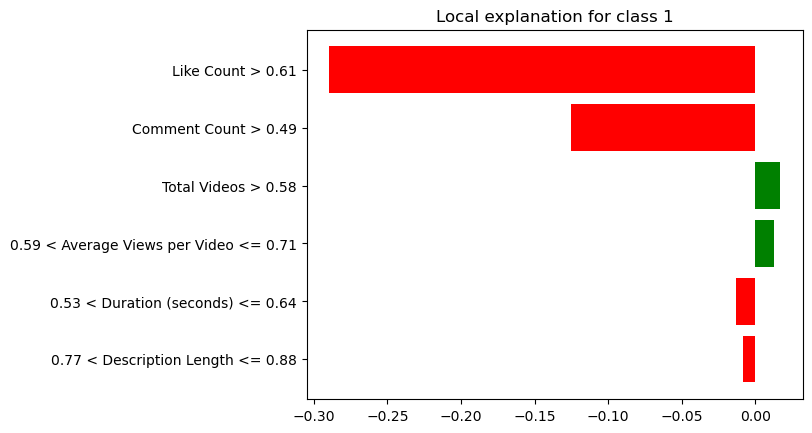

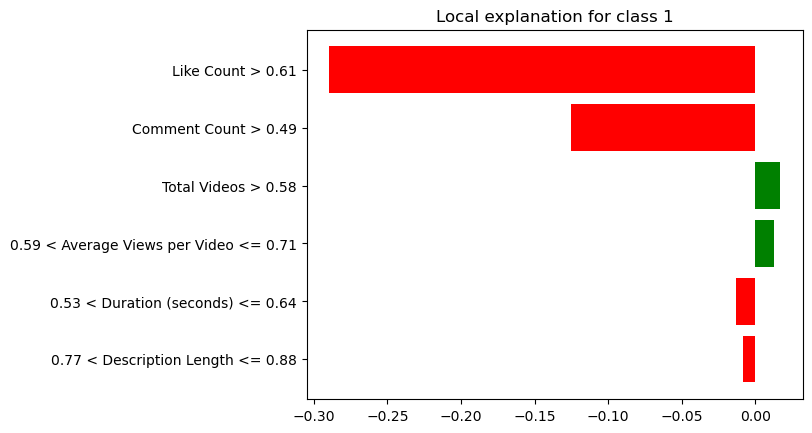

In [74]:
# Visualize feature contributions for the instance
explanation.as_pyplot_figure()
